In [1]:
%load_ext autoreload
%autoreload 2
%run ../src/main.py

In [2]:
display(df.head())

,high,low,close,open,volume,EMA_3,EMA_5,EMA_8,EMA_10,EMA_12,...,MFE_48,MFE_96,MFE_192,MFE_384,MFE_720,ADX,MACD_Hist,Primary_Signal,Barrier_Label,Meta_Target_Binary
unix_time,,,,,,,,,,,,,,,,,,,,,
1577836,7190.52,7170.15,7171.55,7189.43,2449.049,7171.550000,7171.550000,7171.550000,7171.550000,7171.550000,...,0.012393,0.032870,0.180835,0.243971,0.338483,NaN,NaN,0,NaN,NaN
1577840,7225.00,7171.10,7210.24,7171.43,3865.038,7190.895000,7184.446667,7180.147778,7178.584545,7177.502308,...,0.006961,0.027328,0.174499,0.237296,0.331301,NaN,NaN,0,NaN,NaN
1577844,7239.30,7206.46,7237.99,7210.38,3228.365,7214.442500,7202.294444,7193.001605,7189.385537,7186.808107,...,0.003100,0.034541,0.169996,0.232552,0.326197,NaN,NaN,0,NaN,NaN
1577847,7239.74,7215.00,7221.65,7237.41,2513.307,7218.046250,7208.746296,7199.367915,7195.251803,7192.168398,...,0.005370,0.036882,0.172643,0.235341,0.329198,NaN,NaN,0,NaN,NaN
1577851,7225.41,7211.22,7213.86,7221.80,1176.666,7215.953125,7210.450864,7202.588378,7198.635112,7195.505567,...,0.006456,0.038002,0.173910,0.236675,0.330633,NaN,NaN,0,NaN,NaN


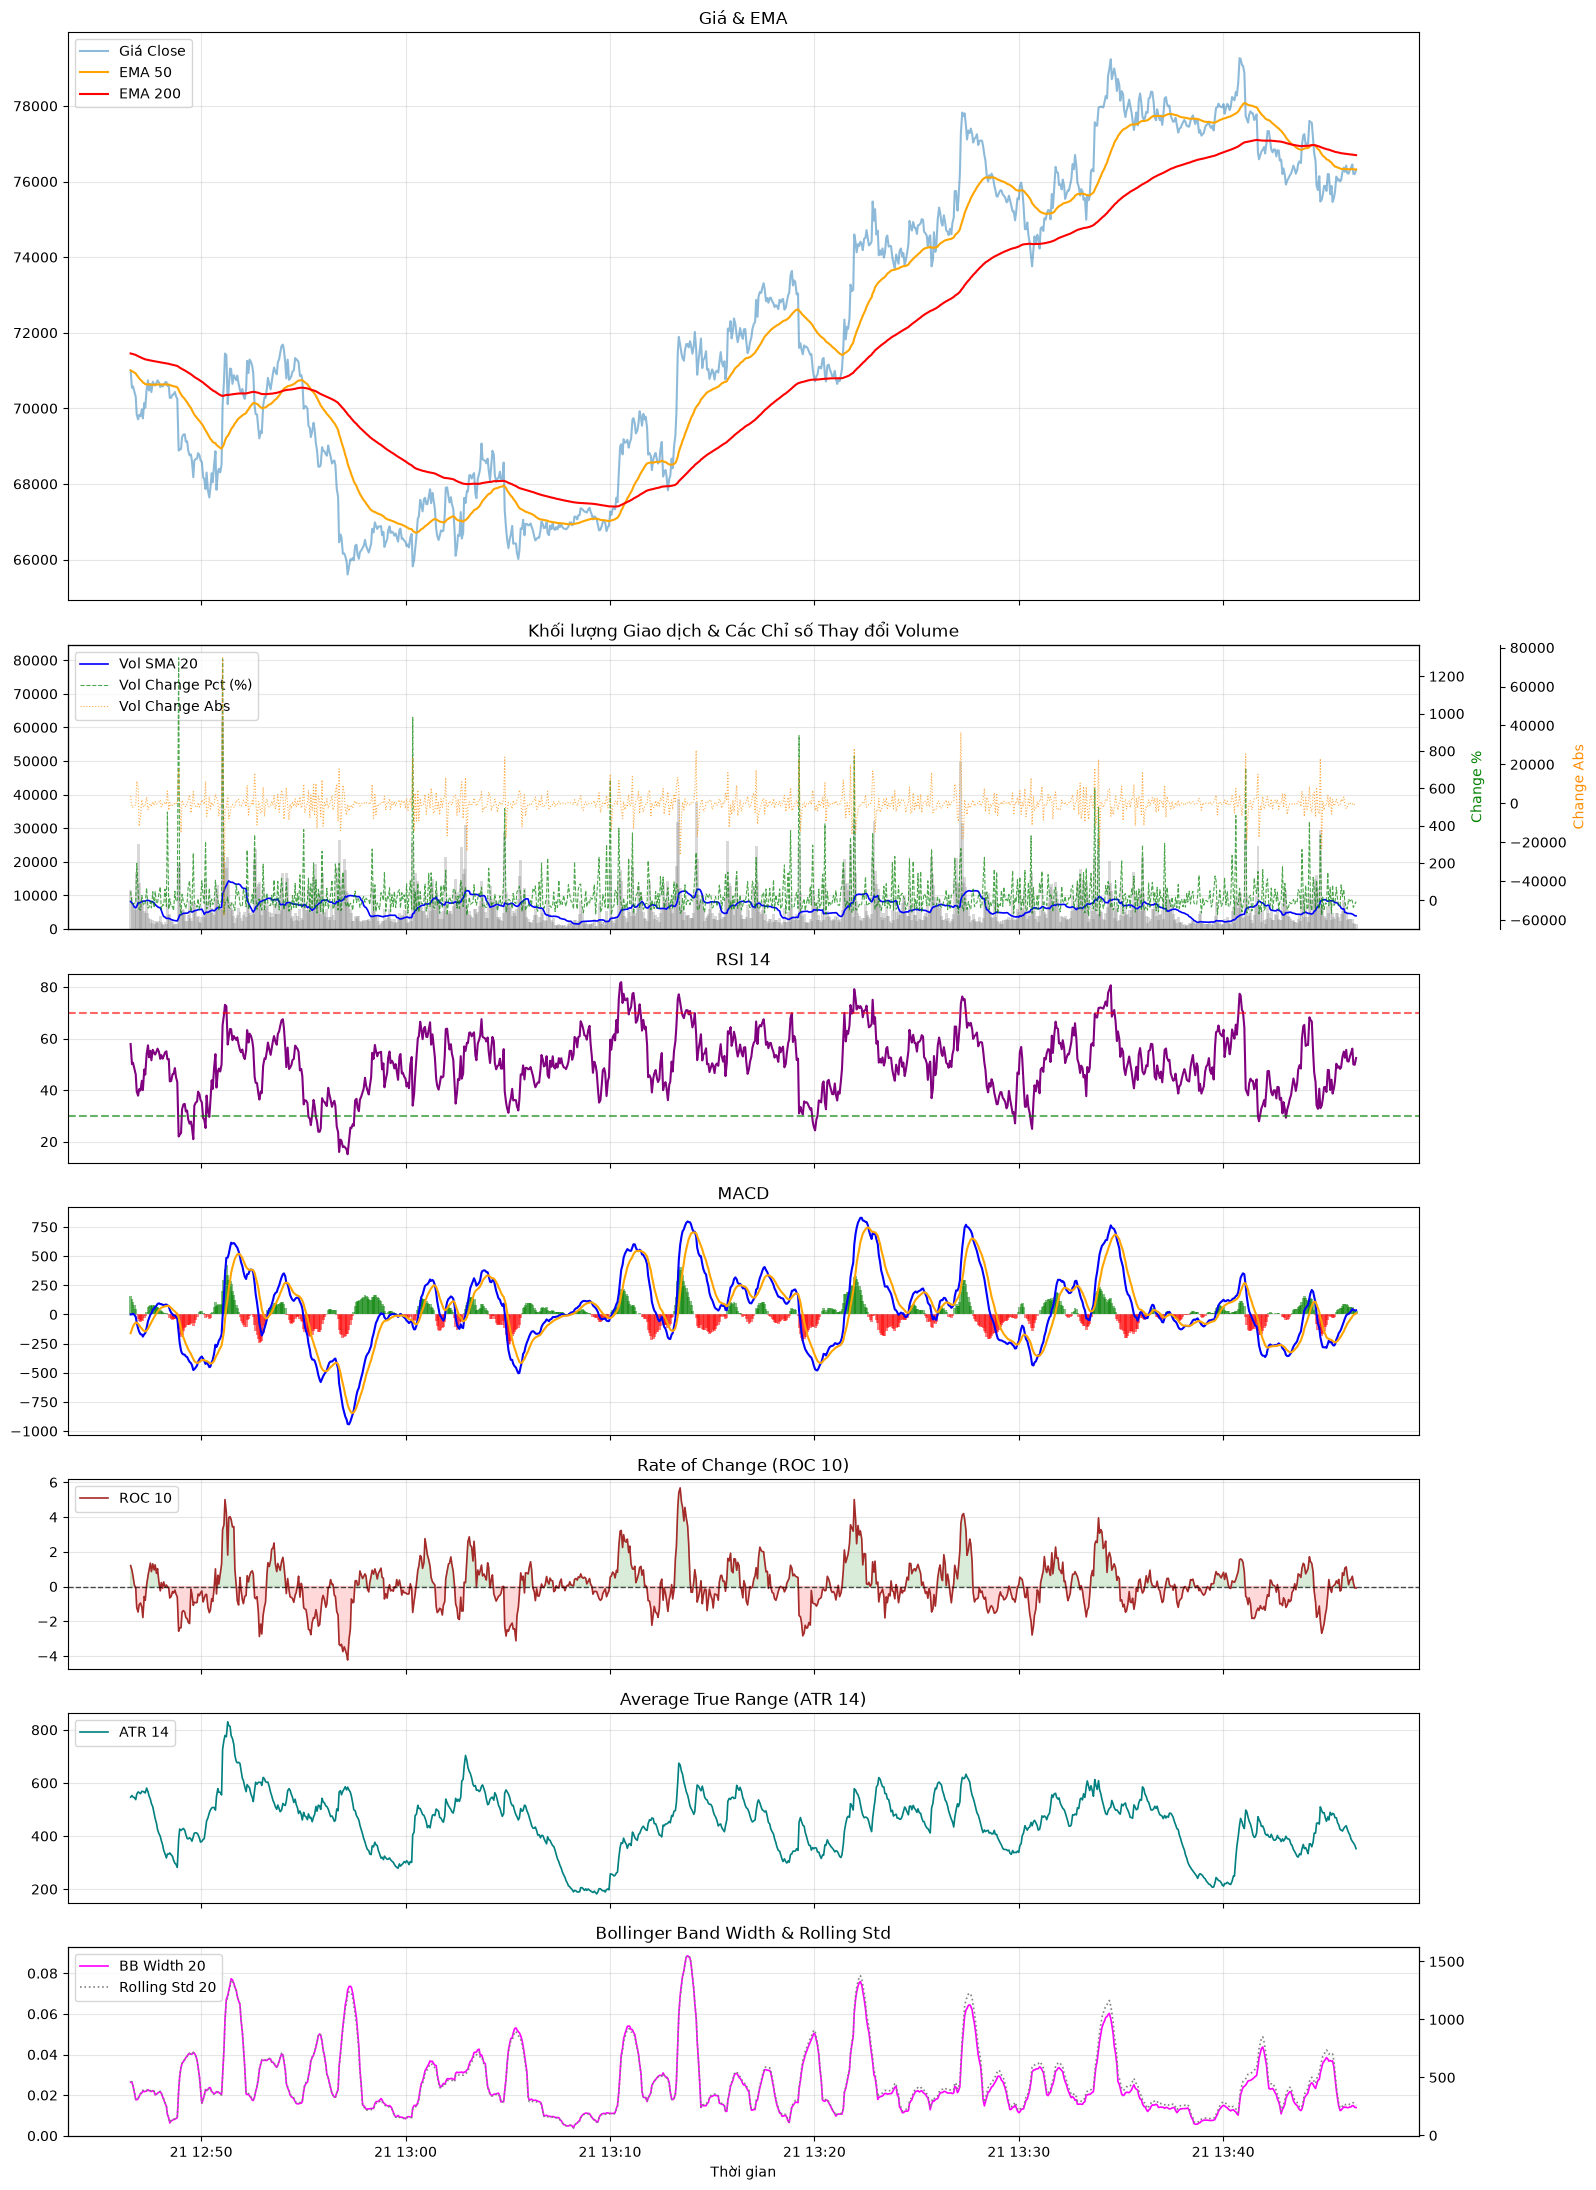

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cắt 1000 nến cuối từ các DataFrame có sẵn
df_zoom = df.tail(1000).copy()
ema_zoom = df.tail(1000).copy()
rsi_zoom = df.tail(1000).copy()
macd_zoom = df.tail(1000).copy()
roc_zoom = df.tail(1000).copy()
atr_zoom = df.tail(1000).copy()
bb_zoom = df.tail(1000).copy()
rstd_zoom = df.tail(1000).copy()
vol_zoom = df.tail(1000).copy()

# 2. Chuyển Index của bản zoom sang Datetime CHỈ ĐỂ VẼ
df_zoom.index = pd.to_datetime(df_zoom.index, unit='s')
ema_zoom.index = df_zoom.index
rsi_zoom.index = df_zoom.index
macd_zoom.index = df_zoom.index
roc_zoom.index = df_zoom.index
atr_zoom.index = df_zoom.index
bb_zoom.index = df_zoom.index
rstd_zoom.index = df_zoom.index
vol_zoom.index = df_zoom.index

# 3. Tạo 7 Subplot xếp chồng
fig, (ax1, ax2, ax3, ax4, ax5, ax6, ax7) = plt.subplots(
    7,
    1,
    figsize=(16, 22),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1.5, 1, 1.2, 1, 1, 1]},
)

# --- 1. GIÁ & EMA ---
ax1.plot(df_zoom.index, df_zoom['close'], label='Giá Close', alpha=0.5)
ax1.plot(ema_zoom.index, ema_zoom['EMA_50'], label='EMA 50', color='orange')
ax1.plot(ema_zoom.index, ema_zoom['EMA_200'], label='EMA 200', color='red')
ax1.set_title('Giá & EMA')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- 2. VOLUME, VOL SMA, VOL CHANGE PCT & VOL CHANGE ABS ---
ax2.bar(
    df_zoom.index,
    df_zoom['volume'],
    color='gray',
    alpha=0.3,
    label='Volume',
    width=0.0001,
)
if 'Vol_SMA_20' in vol_zoom.columns:
    ax2.plot(
        vol_zoom.index,
        vol_zoom['Vol_SMA_20'],
        color='blue',
        linewidth=1.2,
        label='Vol SMA 20',
    )

# Trục phụ 1 (bên phải): Volume Change Pct (%)
ax2_twin1 = ax2.twinx()
line_pct = []
if 'Vol_Change_Pct' in vol_zoom.columns:
    line_pct = ax2_twin1.plot(
        vol_zoom.index,
        vol_zoom['Vol_Change_Pct'],
        color='green',
        linestyle='--',
        alpha=0.7,
        linewidth=0.8,
        label='Vol Change Pct (%)',
    )
    ax2_twin1.set_ylabel('Change %', color='green')

# Trục phụ 2 (bên phải, lệch ra ngoài): Volume Change Abs
ax2_twin2 = ax2.twinx()
ax2_twin2.spines['right'].set_position(('axes', 1.06))
line_abs = []
if 'Vol_Change_Abs' in vol_zoom.columns:
    line_abs = ax2_twin2.plot(
        vol_zoom.index,
        vol_zoom['Vol_Change_Abs'],
        color='darkorange',
        linestyle=':',
        alpha=0.7,
        linewidth=0.8,
        label='Vol Change Abs',
    )
    ax2_twin2.set_ylabel('Change Abs', color='darkorange')

# Gộp Chú thích (Legend) cho Subplot 2
lines_vol = ax2.get_lines() + line_pct + line_abs
labels_vol = [l.get_label() for l in lines_vol]
ax2.legend(lines_vol, labels_vol, loc='upper left')
ax2.set_title('Khối lượng Giao dịch & Các Chỉ số Thay đổi Volume')
ax2.grid(True, alpha=0.3)

# --- 3. RSI ---
ax3.plot(rsi_zoom.index, rsi_zoom['RSI_14'], color='purple', label='RSI 14')
ax3.axhline(70, color='red', linestyle='--', alpha=0.6)
ax3.axhline(30, color='green', linestyle='--', alpha=0.6)
ax3.set_title('RSI 14')
ax3.grid(True, alpha=0.3)

# --- 4. MACD ---
ax4.plot(macd_zoom.index, macd_zoom['MACD'], label='MACD', color='blue')
ax4.plot(macd_zoom.index, macd_zoom['Signal'], label='Signal', color='orange')
colors = ['green' if val >= 0 else 'red' for val in macd_zoom['Hist']]
ax4.bar(
    macd_zoom.index,
    macd_zoom['Hist'],
    color=colors,
    alpha=0.5,
    label='Hist',
    width=0.0001,
)
ax4.set_title('MACD')
ax4.grid(True, alpha=0.3)

# --- 5. ROC ---
ax5.plot(
    roc_zoom.index,
    roc_zoom['ROC_10'],
    color='brown',
    linewidth=1.2,
    label='ROC 10',
)
ax5.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax5.fill_between(
    roc_zoom.index,
    roc_zoom['ROC_10'],
    0,
    where=(roc_zoom['ROC_10'] >= 0),
    color='green',
    alpha=0.15,
)
ax5.fill_between(
    roc_zoom.index,
    roc_zoom['ROC_10'],
    0,
    where=(roc_zoom['ROC_10'] < 0),
    color='red',
    alpha=0.15,
)
ax5.set_title('Rate of Change (ROC 10)')
ax5.legend(loc='upper left')
ax5.grid(True, alpha=0.3)

# --- 6. ATR ---
ax6.plot(
    atr_zoom.index,
    atr_zoom['ATR_14'],
    color='teal',
    linewidth=1.2,
    label='ATR 14',
)
ax6.set_title('Average True Range (ATR 14)')
ax6.legend(loc='upper left')
ax6.grid(True, alpha=0.3)

# --- 7. BOLLINGER WIDTH & ROLLING STD ---
ax7_twin = ax7.twinx()
line1 = ax7.plot(
    bb_zoom.index,
    bb_zoom['BB_Width_20'],
    color='magenta',
    linewidth=1.2,
    label='BB Width 20',
)
line2 = ax7_twin.plot(
    rstd_zoom.index,
    rstd_zoom['Rolling_Std_20'],
    color='gray',
    linestyle=':',
    linewidth=1.2,
    label='Rolling Std 20',
)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax7.legend(lines, labels, loc='upper left')

ax7.set_title('Bollinger Band Width & Rolling Std')
ax7.set_xlabel('Thời gian')
ax7.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

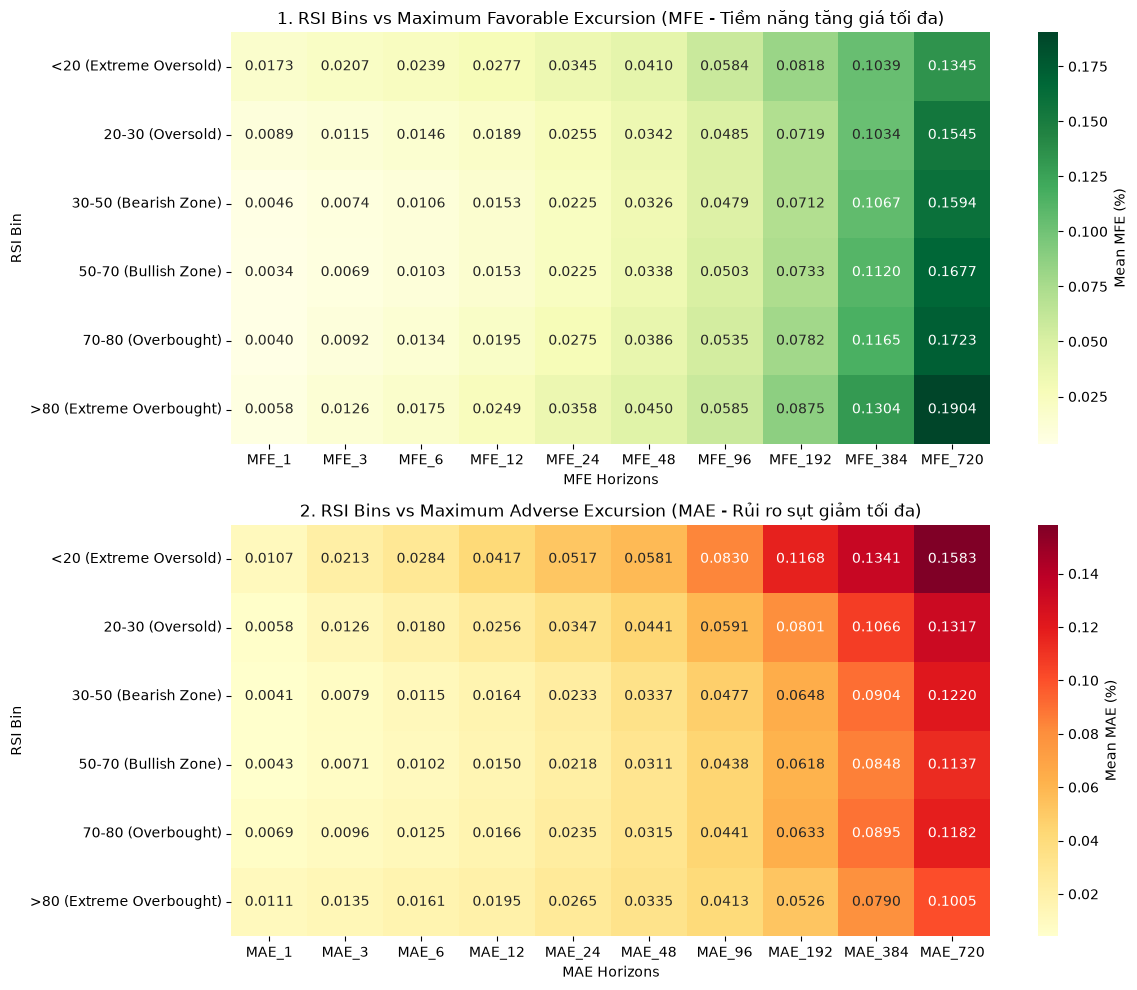

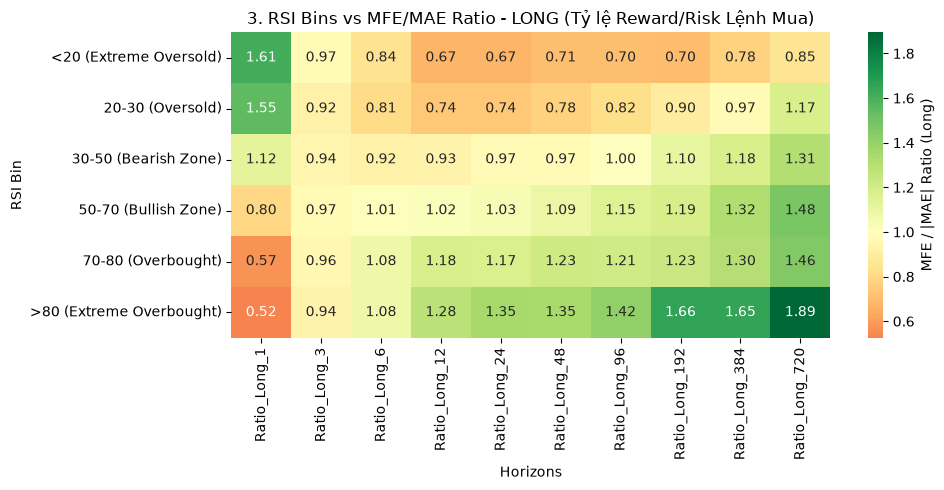

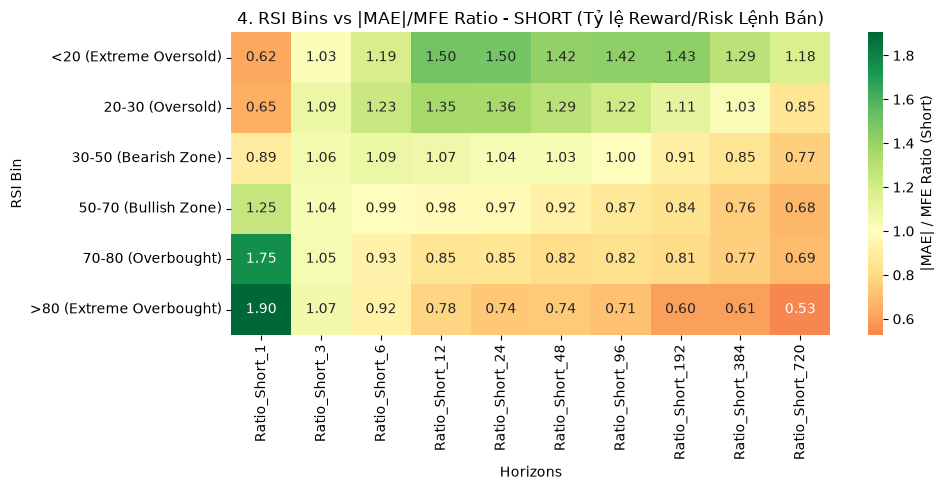

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# GIỮ NGUYÊN CODE GỐC CỦA BẠN (LONG POSITION)
# ==========================================

# 1. Tự động lọc các cột MFE_{n} và MAE_{n} có sẵn trong df
mfe_cols = sorted([col for col in df.columns if col.startswith('MFE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)
mae_cols = sorted([col for col in df.columns if col.startswith('MAE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)

# Mốc phân loại RSI tiêu chuẩn
bins = [0, 20, 30, 50, 70, 80, 100]
labels = ['<20 (Extreme Oversold)', '20-30 (Oversold)', '30-50 (Bearish Zone)', 
          '50-70 (Bullish Zone)', '70-80 (Overbought)', '>80 (Extreme Overbought)']

df['rsi_bin'] = pd.cut(df['RSI_14'], bins=bins, labels=labels, include_lowest=True)

# 2. Gom nhóm theo rsi_bin và tính giá trị trung bình
mfe_summary = df.groupby('rsi_bin', observed=False)[mfe_cols].mean()
mae_summary = df.groupby('rsi_bin', observed=False)[mae_cols].mean()

# 3. Vẽ Heatmap so sánh MFE và MAE
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# Graph 1: MFE Heatmap (Tiềm năng lợi nhuận tối đa)
sns.heatmap(
    mfe_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlGn",          # Càng xanh đậm = MFE càng cao (Tốt)
    cbar_kws={'label': 'Mean MFE (%)'},
    ax=axes[0]
)
axes[0].set_title('1. RSI Bins vs Maximum Favorable Excursion (MFE - Tiềm năng tăng giá tối đa)', fontsize=12)
axes[0].set_xlabel('MFE Horizons')
axes[0].set_ylabel('RSI Bin')

# Graph 2: MAE Heatmap (Mức sụt giảm rủi ro tối đa)
sns.heatmap(
    mae_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlOrRd",        # Càng đỏ đậm = MAE âm/sâu hơn (Rủi ro cao)
    cbar_kws={'label': 'Mean MAE (%)'},
    ax=axes[1]
)
axes[1].set_title('2. RSI Bins vs Maximum Adverse Excursion (MAE - Rủi ro sụt giảm tối đa)', fontsize=12)
axes[1].set_xlabel('MAE Horizons')
axes[1].set_ylabel('RSI Bin')

plt.tight_layout()
plt.show()


# ==========================================
# BỔ SUNG: TỶ LỆ MFE / MAE (MFE/MAE Ratio - LONG)
# ==========================================
# Đo lường tỷ lệ Reward/Risk tự nhiên tại từng vùng RSI cho lệnh Mua
if len(mfe_cols) == len(mae_cols):
    ratio_summary = mfe_summary.values / np.abs(mae_summary.values)
    ratio_df = pd.DataFrame(ratio_summary, index=mfe_summary.index, columns=[col.replace('MFE_', 'Ratio_Long_') for col in mfe_cols])

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0,         # Mốc 1.0: MFE bằng MAE (Cân bằng Reward/Risk)
        cbar_kws={'label': 'MFE / |MAE| Ratio (Long)'},
        ax=ax
    )
    ax.set_title('3. RSI Bins vs MFE/MAE Ratio - LONG (Tỷ lệ Reward/Risk Lệnh Mua)', fontsize=12)
    ax.set_xlabel('Horizons')
    ax.set_ylabel('RSI Bin')

    plt.tight_layout()
    plt.show()


# ==========================================
# THÊM MỚI: LẬT NGƯỢC TỶ LỆ CHO LỆNH BÁN (SHORT R:R)
# ==========================================
# Đối với lệnh Short: 
# - Reward (Mức giảm sâu nhất của giá) = |MAE| (Tốc độ giảm/mức giảm tuyệt đối)
# - Risk (Mức tăng giá ngược chiều) = MFE (Mức giá tăng cao nhất làm vị thế Short bị lỗ)
# -> Short R:R Ratio = |MAE| / MFE
if len(mfe_cols) == len(mae_cols):
    short_ratio_summary = np.abs(mae_summary.values) / np.where(mfe_summary.values == 0, np.nan, mfe_summary.values)
    short_ratio_df = pd.DataFrame(short_ratio_summary, index=mfe_summary.index, columns=[col.replace('MFE_', 'Ratio_Short_') for col in mfe_cols])

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        short_ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0,         # Mốc 1.0: Mức giảm bằng mức tăng (>1.0 là lệnh Short có lợi)
        cbar_kws={'label': '|MAE| / MFE Ratio (Short)'},
        ax=ax
    )
    ax.set_title('4. RSI Bins vs |MAE|/MFE Ratio - SHORT (Tỷ lệ Reward/Risk Lệnh Bán)', fontsize=12)
    ax.set_xlabel('Horizons')
    ax.set_ylabel('RSI Bin')

    plt.tight_layout()
    plt.show()

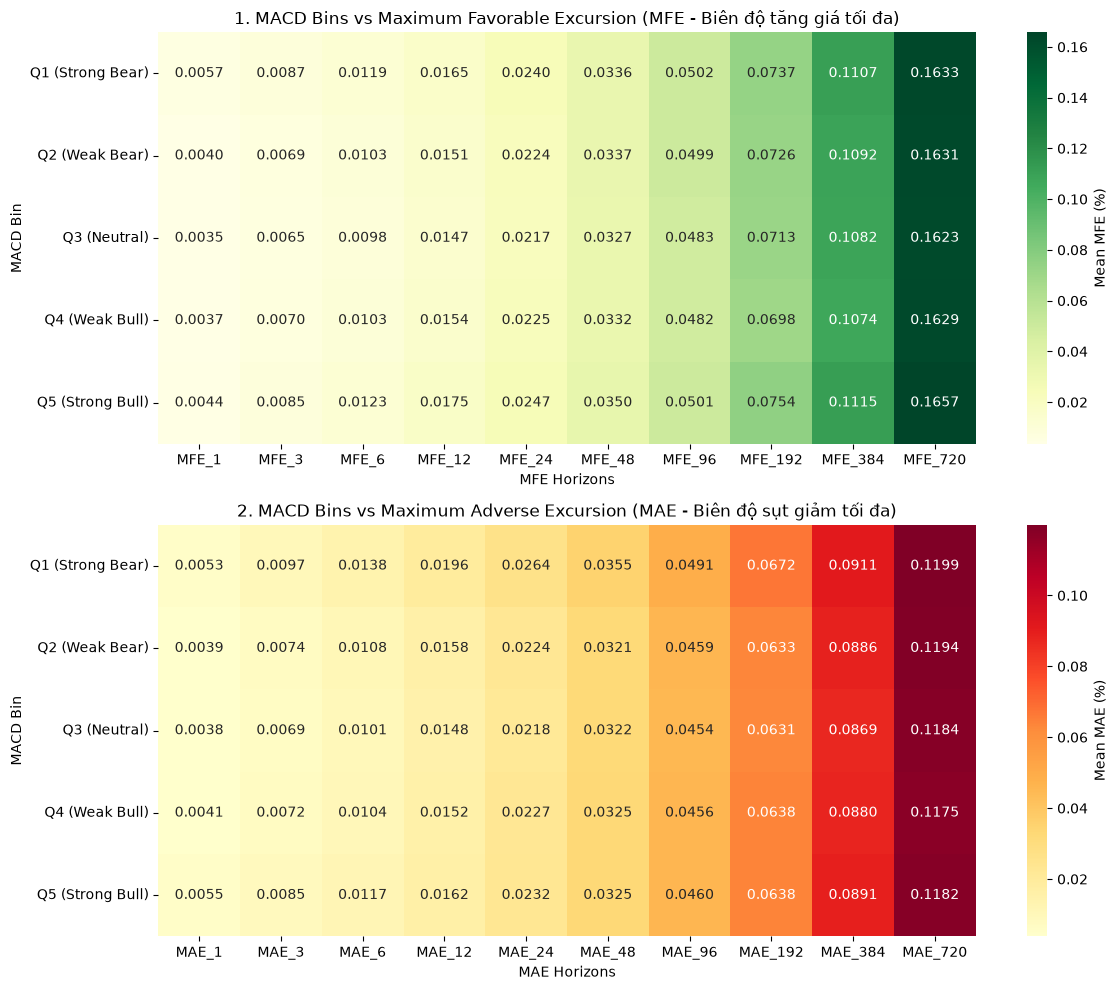

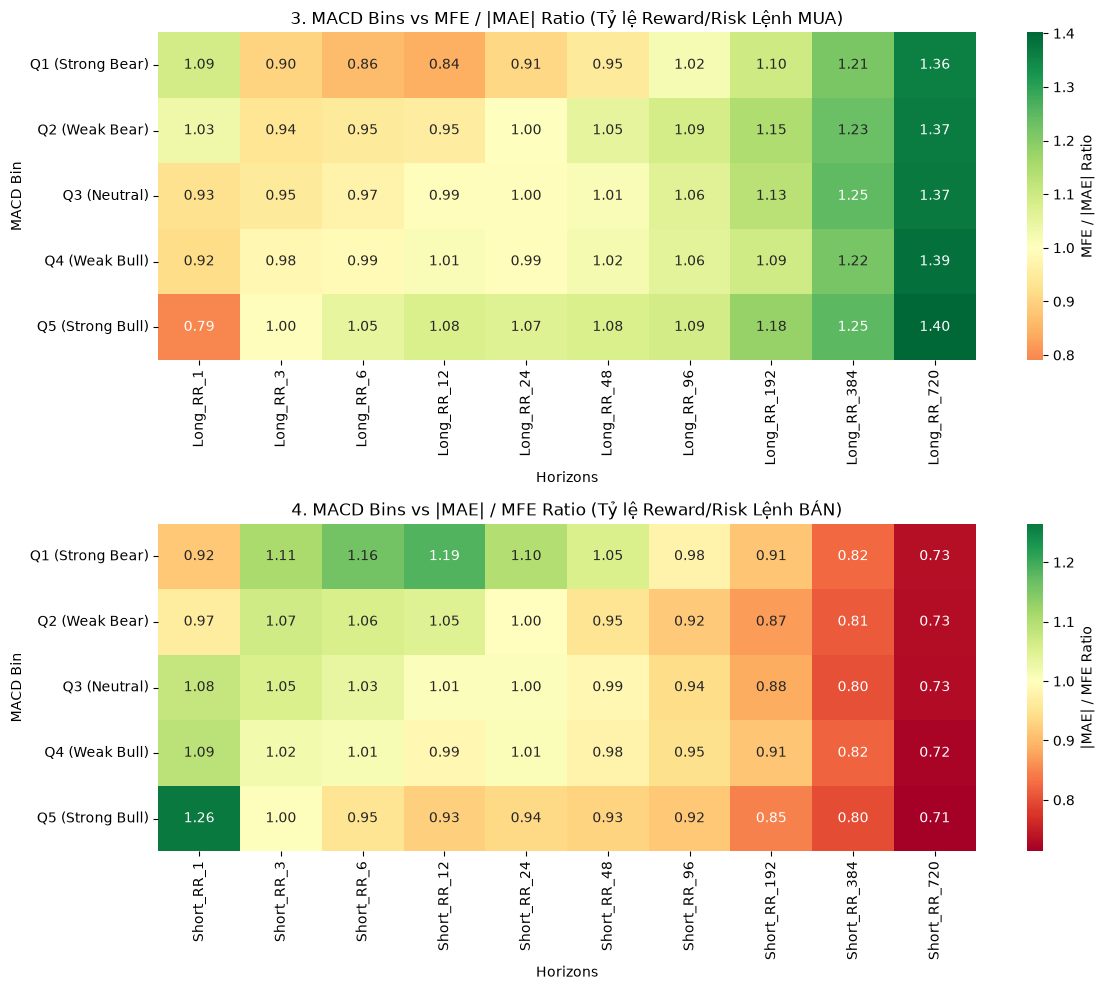

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. TIỀN XỬ LÝ DỮ LIỆU MACD (Nếu df chưa có macd_bin)
# ==========================================
if 'macd_bin' not in df.columns:
    # Tính MACD (12, 26, 9)
    ema_12 = df['close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['close'].ewm(span=26, adjust=False).mean()
    macd_line = ema_12 - ema_26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = macd_line - signal_line  # Dùng Histogram đại diện cho xung lực

# Chia MACD_Hist thành 5 Bins từ Bearish mạnh đến Bullish mạnh
hist = df['MACD_Hist']
window = 200

# Tính các ngưỡng phân vị trượt chỉ dùng dữ liệu quá khứ
q20 = hist.rolling(window).quantile(0.20)
q40 = hist.rolling(window).quantile(0.40)
q60 = hist.rolling(window).quantile(0.60)
q80 = hist.rolling(window).quantile(0.80)

# Điều kiện phân nhóm
conditions = [
    hist <= q20,
    (hist > q20) & (hist <= q40),
    (hist > q40) & (hist <= q60),
    (hist > q60) & (hist <= q80),
    hist > q80
]

labels = ['Q1 (Strong Bear)', 'Q2 (Weak Bear)', 'Q3 (Neutral)', 'Q4 (Weak Bull)', 'Q5 (Strong Bull)']

macd_bin = pd.Series(
    np.select(conditions, labels, default=None), 
    index=df.index, 
    name='macd_bin'
)

df['macd_bin'] = macd_bin
df = df.copy()

# ==========================================
# 2. LỌC CÁC CỘT MFE VÀ MAE CÓ SẴN TRONG DF
# ==========================================
mfe_cols = sorted([col for col in df.columns if col.startswith('MFE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)
mae_cols = sorted([col for col in df.columns if col.startswith('MAE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)

# Gom nhóm theo macd_bin và tính giá trị trung bình
mfe_summary = df.groupby('macd_bin', observed=False)[mfe_cols].mean()
mae_summary = df.groupby('macd_bin', observed=False)[mae_cols].mean()

# ==========================================
# 3. TRỰC QUAN HÓA MFE VÀ MAE
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# Graph 1: MFE Heatmap
sns.heatmap(
    mfe_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlGn", 
    cbar_kws={'label': 'Mean MFE (%)'},
    ax=axes[0]
)
axes[0].set_title('1. MACD Bins vs Maximum Favorable Excursion (MFE - Biên độ tăng giá tối đa)', fontsize=12)
axes[0].set_xlabel('MFE Horizons')
axes[0].set_ylabel('MACD Bin')

# Graph 2: MAE Heatmap
sns.heatmap(
    mae_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Mean MAE (%)'},
    ax=axes[1]
)
axes[1].set_title('2. MACD Bins vs Maximum Adverse Excursion (MAE - Biên độ sụt giảm tối đa)', fontsize=12)
axes[1].set_xlabel('MAE Horizons')
axes[1].set_ylabel('MACD Bin')

plt.tight_layout()
plt.show()

# ==========================================
# 4. TRỰC QUAN HÓA TỶ LỆ MFE/MAE (LONG R:R) VÀ MAE/MFE (SHORT R:R)
# ==========================================
if len(mfe_cols) == len(mae_cols):
    # Long R:R = MFE / |MAE|
    long_ratio = mfe_summary.values / np.abs(mae_summary.values)
    long_ratio_df = pd.DataFrame(long_ratio, index=mfe_summary.index, columns=[col.replace('MFE_', 'Long_RR_') for col in mfe_cols])

    # Short R:R = |MAE| / MFE
    short_ratio = np.abs(mae_summary.values) / np.where(mfe_summary.values == 0, np.nan, mfe_summary.values)
    short_ratio_df = pd.DataFrame(short_ratio, index=mfe_summary.index, columns=[col.replace('MFE_', 'Short_RR_') for col in mfe_cols])

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    # Graph 3: MFE / |MAE| Ratio (Lệnh Mua)
    sns.heatmap(
        long_ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0, 
        cbar_kws={'label': 'MFE / |MAE| Ratio'},
        ax=axes[0]
    )
    axes[0].set_title('3. MACD Bins vs MFE / |MAE| Ratio (Tỷ lệ Reward/Risk Lệnh MUA)', fontsize=12)
    axes[0].set_xlabel('Horizons')
    axes[0].set_ylabel('MACD Bin')

    # Graph 4: |MAE| / MFE Ratio (Lệnh Bán)
    sns.heatmap(
        short_ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0, 
        cbar_kws={'label': '|MAE| / MFE Ratio'},
        ax=axes[1]
    )
    axes[1].set_title('4. MACD Bins vs |MAE| / MFE Ratio (Tỷ lệ Reward/Risk Lệnh BÁN)', fontsize=12)
    axes[1].set_xlabel('Horizons')
    axes[1].set_ylabel('MACD Bin')

    plt.tight_layout()
    plt.show()

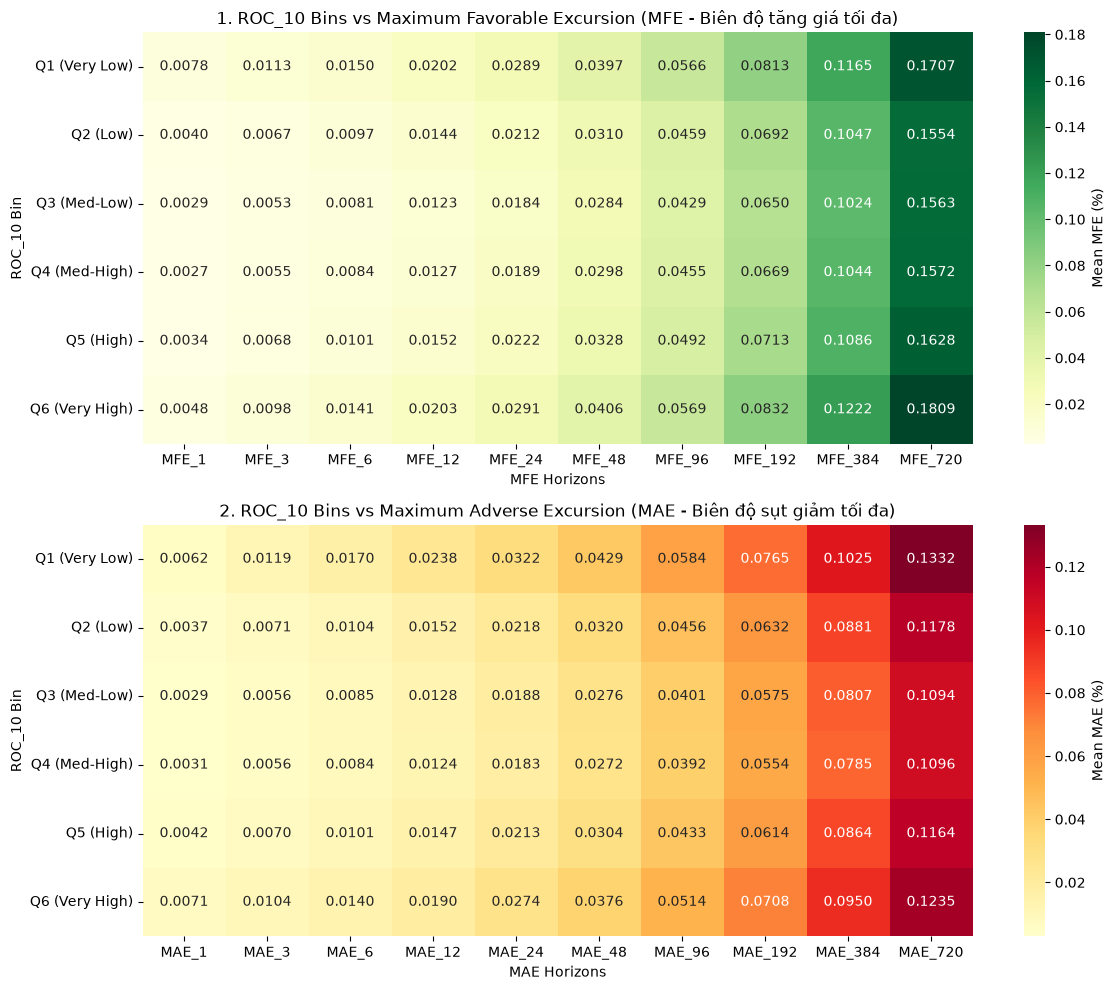

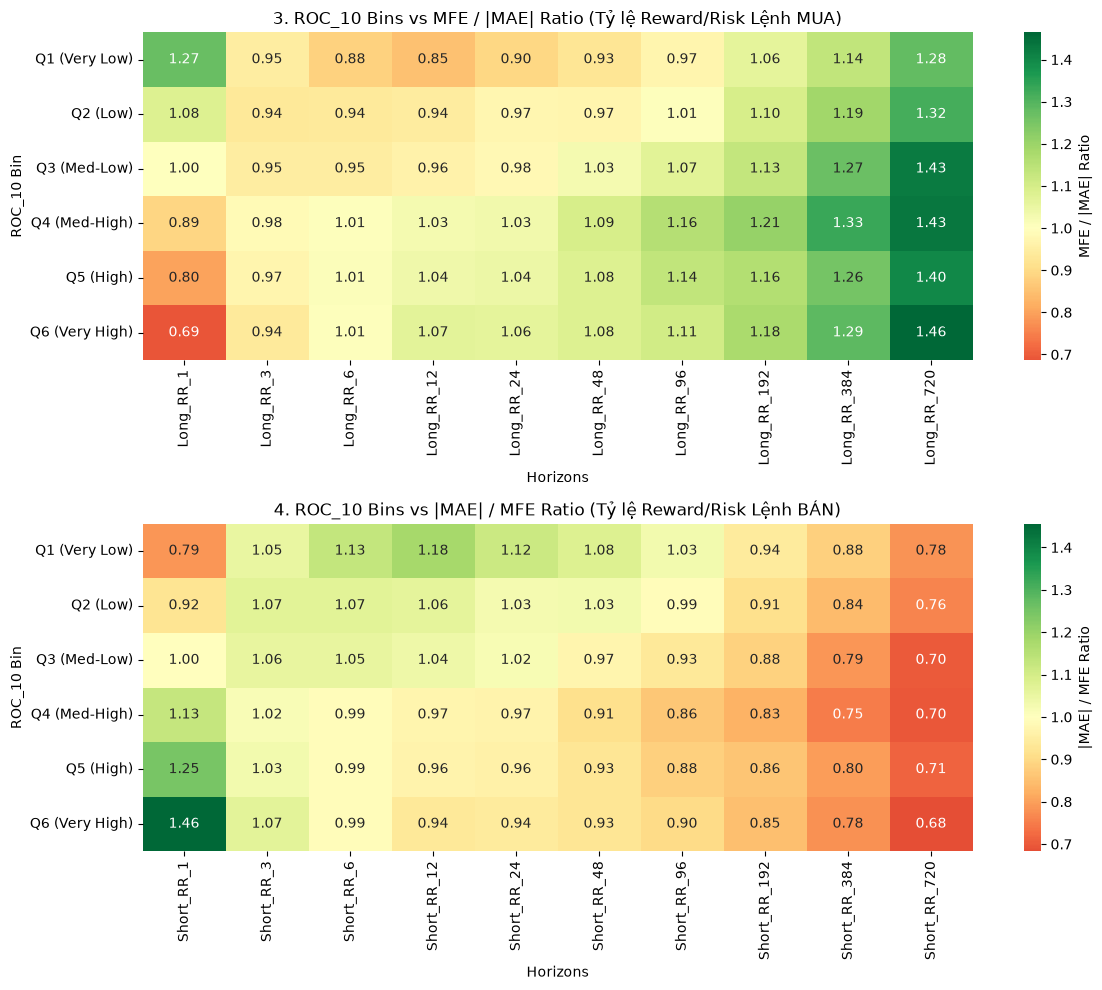

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. TIỀN XỬ LÝ ROC_10 & TÁI CẤU TRÚC BỘ NHỚ
# ==========================================
if 'ROC_10' not in df.columns:
    df['ROC_10'] = (df['Close'] / df['Close'].shift(10) - 1) * 100

if 'roc10_bin' not in df.columns:
    roc_labels = ['Q1 (Very Low)', 'Q2 (Low)', 'Q3 (Med-Low)', 'Q4 (Med-High)', 'Q5 (High)', 'Q6 (Very High)']
    roc10_bin = pd.qcut(df['ROC_10'].dropna(), q=6, labels=roc_labels)
    df = pd.concat([df, pd.DataFrame({'roc10_bin': roc10_bin})], axis=1)

# Tái cấu trúc bộ nhớ tránh PerformanceWarning
df = df.copy()

# ==========================================
# 2. LỌC CÁC CỘT MFE VÀ MAE CÓ SẴN TRONG DF
# ==========================================
mfe_cols = sorted([col for col in df.columns if col.startswith('MFE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)
mae_cols = sorted([col for col in df.columns if col.startswith('MAE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)

# Gom nhóm theo roc10_bin và tính giá trị trung bình
mfe_summary = df.groupby('roc10_bin', observed=False)[mfe_cols].mean()
mae_summary = df.groupby('roc10_bin', observed=False)[mae_cols].mean()

# ==========================================
# 3. TRỰC QUAN HÓA MFE VÀ MAE
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# Graph 1: MFE Heatmap (Lợi nhuận tiềm năng tối đa)
sns.heatmap(
    mfe_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlGn", 
    cbar_kws={'label': 'Mean MFE (%)'},
    ax=axes[0]
)
axes[0].set_title('1. ROC_10 Bins vs Maximum Favorable Excursion (MFE - Biên độ tăng giá tối đa)', fontsize=12)
axes[0].set_xlabel('MFE Horizons')
axes[0].set_ylabel('ROC_10 Bin')

# Graph 2: MAE Heatmap (Rủi ro sụt giảm tối đa)
sns.heatmap(
    mae_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Mean MAE (%)'},
    ax=axes[1]
)
axes[1].set_title('2. ROC_10 Bins vs Maximum Adverse Excursion (MAE - Biên độ sụt giảm tối đa)', fontsize=12)
axes[1].set_xlabel('MAE Horizons')
axes[1].set_ylabel('ROC_10 Bin')

plt.tight_layout()
plt.show()

# ==========================================
# 4. TRỰC QUAN HÓA TỶ LỆ MFE/MAE (LONG R:R) VÀ MAE/MFE (SHORT R:R)
# ==========================================
if len(mfe_cols) == len(mae_cols):
    # Long R:R = MFE / |MAE|
    long_ratio = mfe_summary.values / np.abs(mae_summary.values)
    long_ratio_df = pd.DataFrame(long_ratio, index=mfe_summary.index, columns=[col.replace('MFE_', 'Long_RR_') for col in mfe_cols])

    # Short R:R = |MAE| / MFE
    short_ratio = np.abs(mae_summary.values) / np.where(mfe_summary.values == 0, np.nan, mfe_summary.values)
    short_ratio_df = pd.DataFrame(short_ratio, index=mfe_summary.index, columns=[col.replace('MFE_', 'Short_RR_') for col in mfe_cols])

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    # Graph 3: MFE / |MAE| Ratio (Lệnh Mua)
    sns.heatmap(
        long_ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0, 
        cbar_kws={'label': 'MFE / |MAE| Ratio'},
        ax=axes[0]
    )
    axes[0].set_title('3. ROC_10 Bins vs MFE / |MAE| Ratio (Tỷ lệ Reward/Risk Lệnh MUA)', fontsize=12)
    axes[0].set_xlabel('Horizons')
    axes[0].set_ylabel('ROC_10 Bin')

    # Graph 4: |MAE| / MFE Ratio (Lệnh Bán)
    sns.heatmap(
        short_ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0, 
        cbar_kws={'label': '|MAE| / MFE Ratio'},
        ax=axes[1]
    )
    axes[1].set_title('4. ROC_10 Bins vs |MAE| / MFE Ratio (Tỷ lệ Reward/Risk Lệnh BÁN)', fontsize=12)
    axes[1].set_xlabel('Horizons')
    axes[1].set_ylabel('ROC_10 Bin')

    plt.tight_layout()
    plt.show()

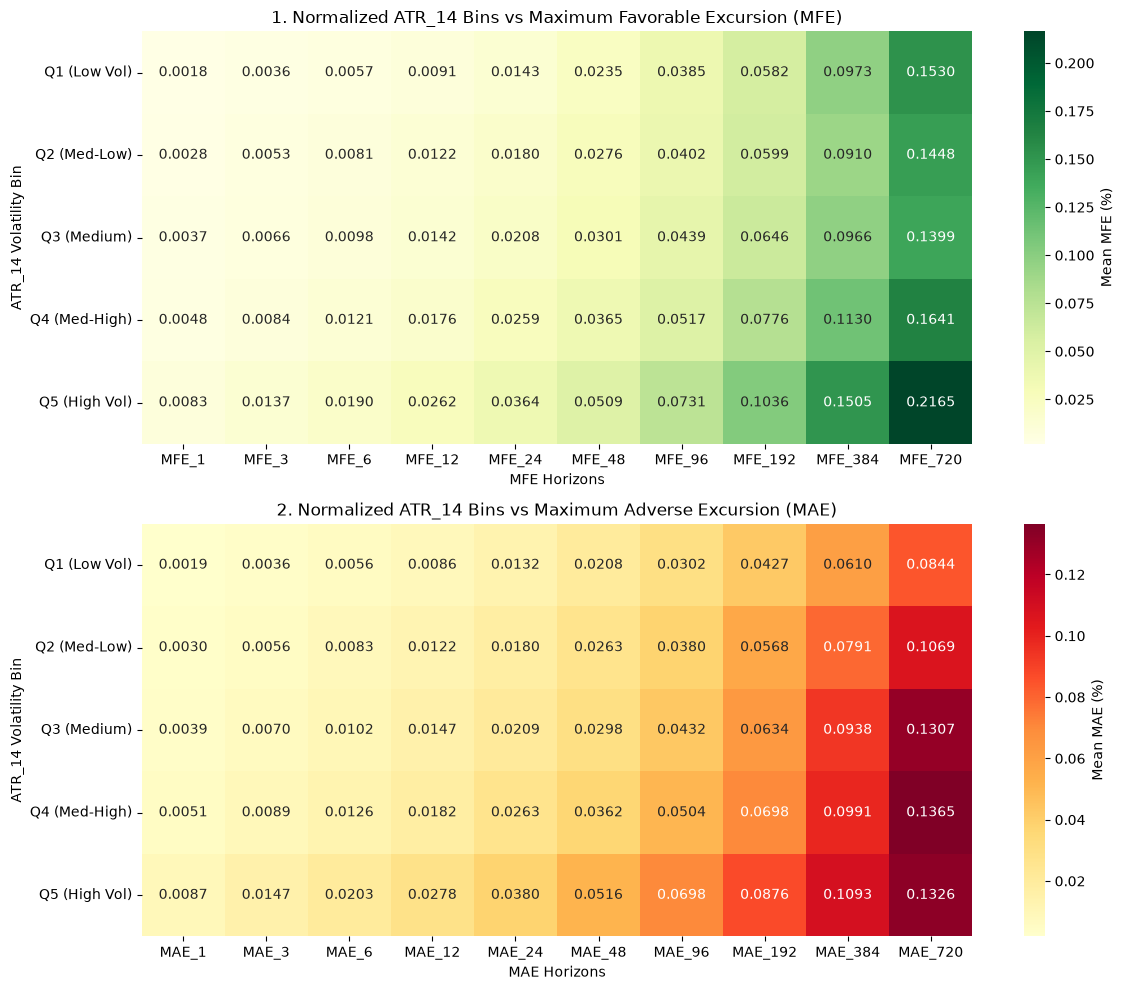

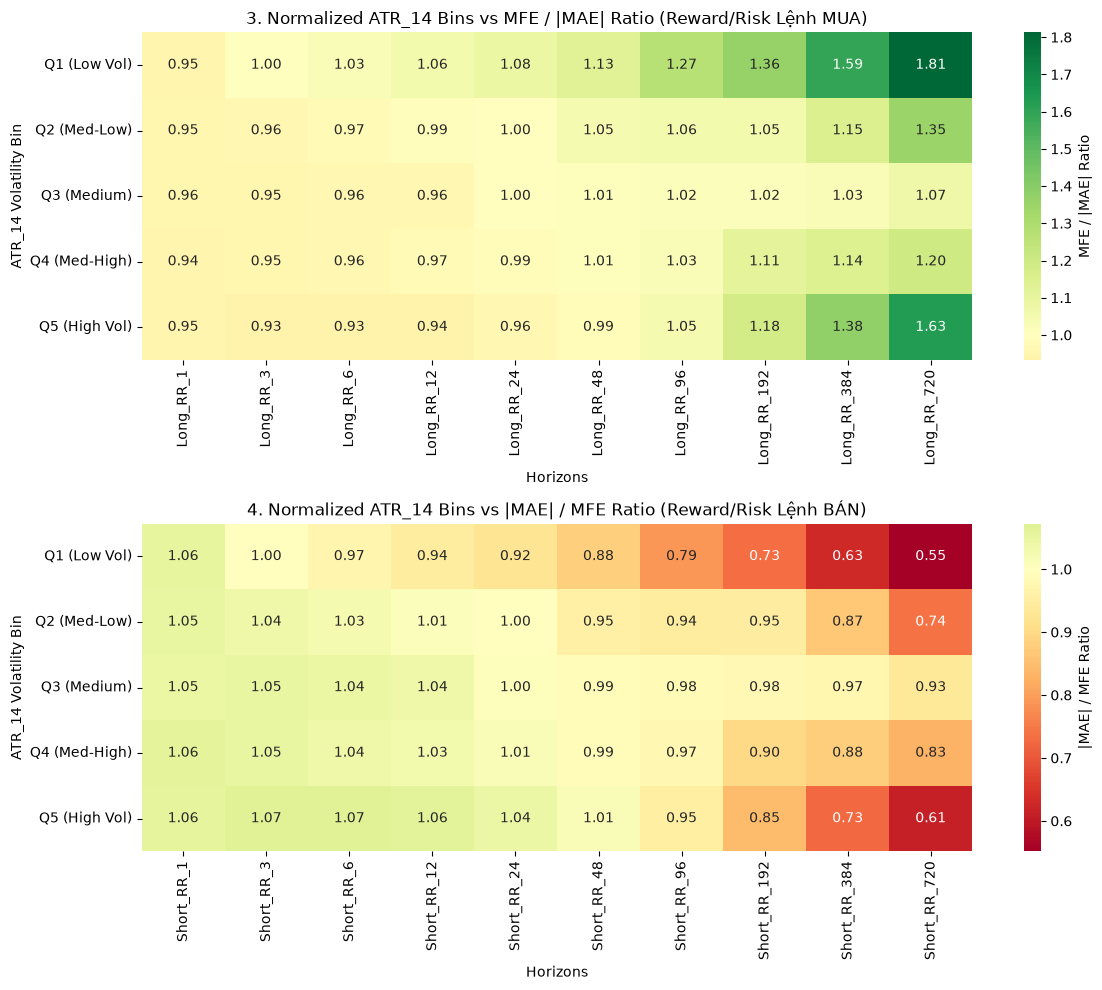

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. TIỀN XỬ LÝ ATR_14 (CHUẨN HÓA % GIÁ & CHIA BIN)
# ==========================================
if 'ATR_14' not in df.columns:
    high_low = df['High'] - df['Low']
    high_close = (df['High'] - df['Close'].shift(1)).abs()
    low_close = (df['Low'] - df['Close'].shift(1)).abs()
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df['ATR_14'] = tr.ewm(alpha=1/14, adjust=False).mean()

if 'atr14_bin' not in df.columns:
    df['ATR_Pct_14'] = (df['ATR_14'] / df['close']) * 100
    atr_labels = ['Q1 (Low Vol)', 'Q2 (Med-Low)', 'Q3 (Medium)', 'Q4 (Med-High)', 'Q5 (High Vol)']
    atr14_bin = pd.qcut(df['ATR_Pct_14'].dropna(), q=5, labels=atr_labels)
    df = pd.concat([df, pd.DataFrame({'atr14_bin': atr14_bin})], axis=1)

# Tái cấu trúc bộ nhớ tránh PerformanceWarning
df = df.copy()

# ==========================================
# 2. LỌC CÁC CỘT MFE VÀ MAE CÓ SẴN TRONG DF
# ==========================================
mfe_cols = sorted([col for col in df.columns if col.startswith('MFE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)
mae_cols = sorted([col for col in df.columns if col.startswith('MAE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)

# Gom nhóm theo atr14_bin và tính giá trị trung bình
mfe_summary = df.groupby('atr14_bin', observed=False)[mfe_cols].mean()
mae_summary = df.groupby('atr14_bin', observed=False)[mae_cols].mean()

# ==========================================
# 3. TRỰC QUAN HÓA MFE VÀ MAE THUẦN TÚY
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# Graph 1: MFE Heatmap (Biên độ tăng giá tối đa)
sns.heatmap(
    mfe_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlGn", 
    cbar_kws={'label': 'Mean MFE (%)'},
    ax=axes[0]
)
axes[0].set_title('1. Normalized ATR_14 Bins vs Maximum Favorable Excursion (MFE)', fontsize=12)
axes[0].set_xlabel('MFE Horizons')
axes[0].set_ylabel('ATR_14 Volatility Bin')

# Graph 2: MAE Heatmap (Biên độ sụt giảm tối đa)
sns.heatmap(
    mae_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Mean MAE (%)'},
    ax=axes[1]
)
axes[1].set_title('2. Normalized ATR_14 Bins vs Maximum Adverse Excursion (MAE)', fontsize=12)
axes[1].set_xlabel('MAE Horizons')
axes[1].set_ylabel('ATR_14 Volatility Bin')

plt.tight_layout()
plt.show()

# ==========================================
# 4. TRỰC QUAN HÓA TỶ LỆ MFE/MAE (LONG R:R) VÀ MAE/MFE (SHORT R:R)
# ==========================================
if len(mfe_cols) == len(mae_cols):
    # Long R:R = MFE / |MAE|
    long_ratio = mfe_summary.values / np.abs(mae_summary.values)
    long_ratio_df = pd.DataFrame(long_ratio, index=mfe_summary.index, columns=[col.replace('MFE_', 'Long_RR_') for col in mfe_cols])

    # Short R:R = |MAE| / MFE
    short_ratio = np.abs(mae_summary.values) / np.where(mfe_summary.values == 0, np.nan, mfe_summary.values)
    short_ratio_df = pd.DataFrame(short_ratio, index=mfe_summary.index, columns=[col.replace('MFE_', 'Short_RR_') for col in mfe_cols])

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    # Graph 3: MFE / |MAE| Ratio (Lệnh Mua)
    sns.heatmap(
        long_ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0, 
        cbar_kws={'label': 'MFE / |MAE| Ratio'},
        ax=axes[0]
    )
    axes[0].set_title('3. Normalized ATR_14 Bins vs MFE / |MAE| Ratio (Reward/Risk Lệnh MUA)', fontsize=12)
    axes[0].set_xlabel('Horizons')
    axes[0].set_ylabel('ATR_14 Volatility Bin')

    # Graph 4: |MAE| / MFE Ratio (Lệnh Bán)
    sns.heatmap(
        short_ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0, 
        cbar_kws={'label': '|MAE| / MFE Ratio'},
        ax=axes[1]
    )
    axes[1].set_title('4. Normalized ATR_14 Bins vs |MAE| / MFE Ratio (Reward/Risk Lệnh BÁN)', fontsize=12)
    axes[1].set_xlabel('Horizons')
    axes[1].set_ylabel('ATR_14 Volatility Bin')

    plt.tight_layout()
    plt.show()

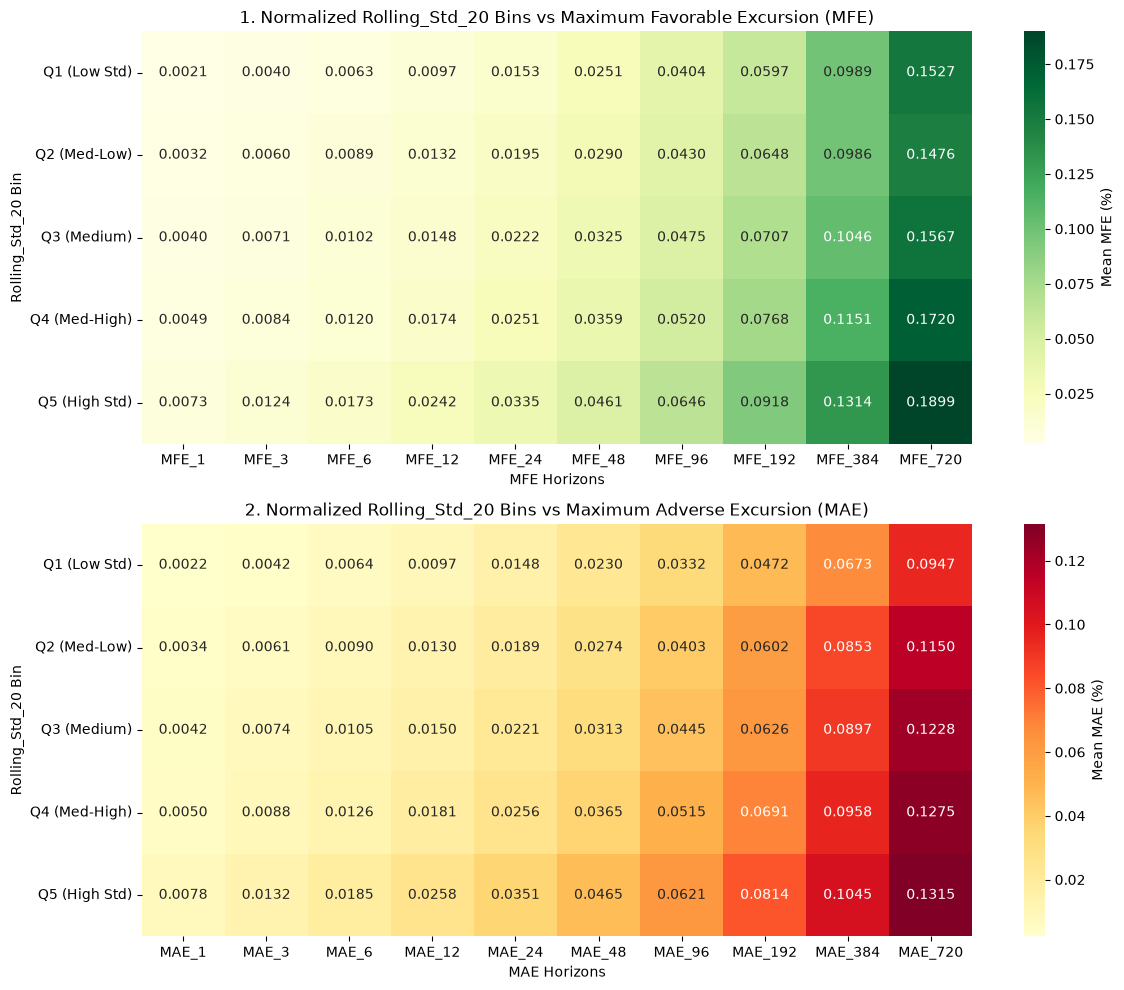

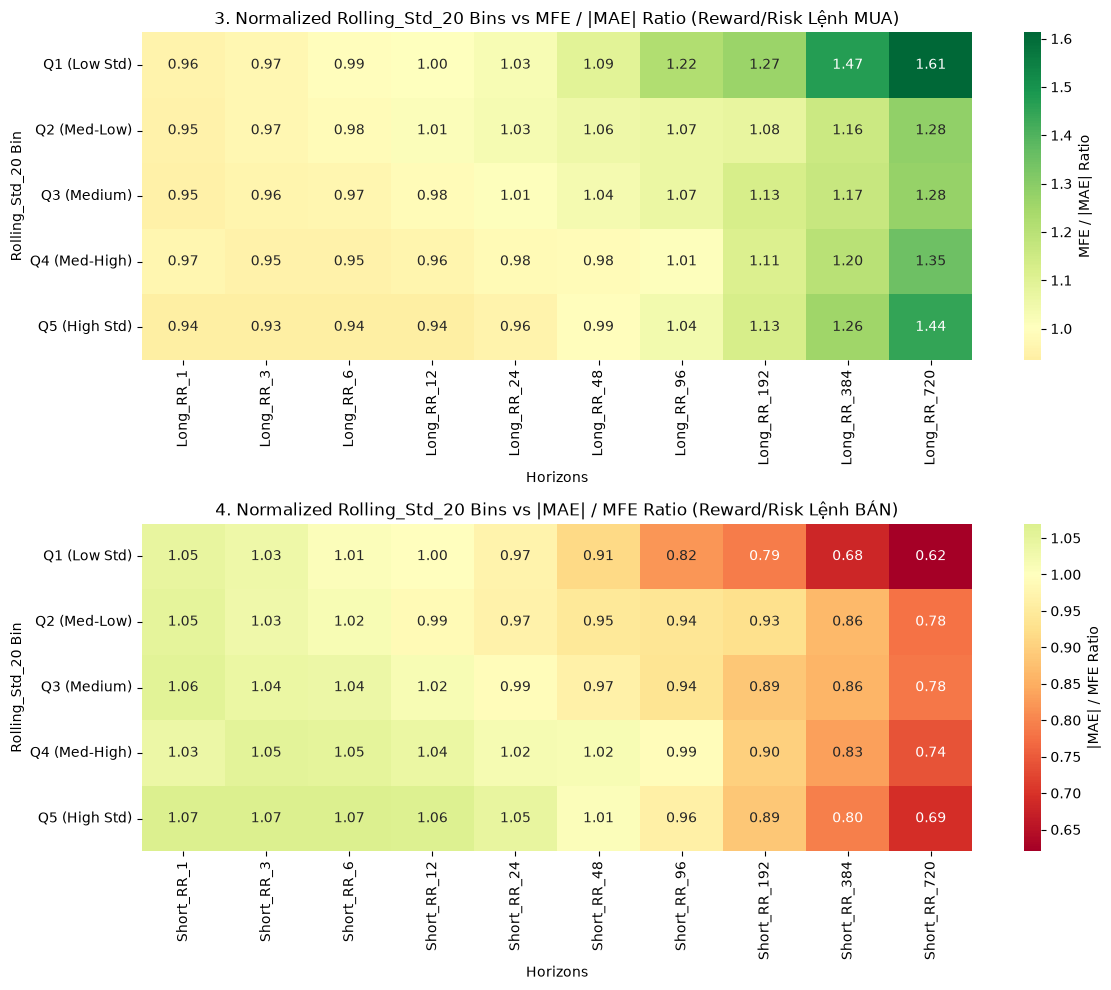

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. TIỀN XỬ LÝ ROLLING_STD_20 (CHUẨN HÓA % GIÁ & CHIA BIN)
# ==========================================
n_std = 20
if f'Rolling_Std_{n_std}' not in df.columns:
    df[f'Rolling_Std_{n_std}'] = df['close'].rolling(n_std).std()

if 'rolling_std_bin' not in df.columns:
    df['Std_Pct_20'] = (df[f'Rolling_Std_{n_std}'] / df['close']) * 100
    std_labels = ['Q1 (Low Std)', 'Q2 (Med-Low)', 'Q3 (Medium)', 'Q4 (Med-High)', 'Q5 (High Std)']
    rolling_std_bin = pd.qcut(df['Std_Pct_20'].dropna(), q=5, labels=std_labels)
    df = pd.concat([df, pd.DataFrame({'rolling_std_bin': rolling_std_bin})], axis=1)

# Tái cấu trúc bộ nhớ tránh PerformanceWarning
df = df.copy()

# ==========================================
# 2. LỌC CÁC CỘT MFE VÀ MAE CÓ SẴN TRONG DF
# ==========================================
mfe_cols = sorted([col for col in df.columns if col.startswith('MFE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)
mae_cols = sorted([col for col in df.columns if col.startswith('MAE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)

# Gom nhóm theo rolling_std_bin và tính giá trị trung bình
mfe_summary = df.groupby('rolling_std_bin', observed=False)[mfe_cols].mean()
mae_summary = df.groupby('rolling_std_bin', observed=False)[mae_cols].mean()

# ==========================================
# 3. TRỰC QUAN HÓA MFE VÀ MAE THUẦN TÚY
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# Graph 1: MFE Heatmap (Biên độ tăng giá tối đa)
sns.heatmap(
    mfe_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlGn", 
    cbar_kws={'label': 'Mean MFE (%)'},
    ax=axes[0]
)
axes[0].set_title('1. Normalized Rolling_Std_20 Bins vs Maximum Favorable Excursion (MFE)', fontsize=12)
axes[0].set_xlabel('MFE Horizons')
axes[0].set_ylabel('Rolling_Std_20 Bin')

# Graph 2: MAE Heatmap (Biên độ sụt giảm tối đa)
sns.heatmap(
    mae_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Mean MAE (%)'},
    ax=axes[1]
)
axes[1].set_title('2. Normalized Rolling_Std_20 Bins vs Maximum Adverse Excursion (MAE)', fontsize=12)
axes[1].set_xlabel('MAE Horizons')
axes[1].set_ylabel('Rolling_Std_20 Bin')

plt.tight_layout()
plt.show()

# ==========================================
# 4. TRỰC QUAN HÓA TỶ LỆ MFE/MAE (LONG R:R) VÀ MAE/MFE (SHORT R:R)
# ==========================================
if len(mfe_cols) == len(mae_cols):
    # Long R:R = MFE / |MAE|
    long_ratio = mfe_summary.values / np.abs(mae_summary.values)
    long_ratio_df = pd.DataFrame(long_ratio, index=mfe_summary.index, columns=[col.replace('MFE_', 'Long_RR_') for col in mfe_cols])

    # Short R:R = |MAE| / MFE
    short_ratio = np.abs(mae_summary.values) / np.where(mfe_summary.values == 0, np.nan, mfe_summary.values)
    short_ratio_df = pd.DataFrame(short_ratio, index=mfe_summary.index, columns=[col.replace('MFE_', 'Short_RR_') for col in mfe_cols])

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    # Graph 3: MFE / |MAE| Ratio (Lệnh Mua)
    sns.heatmap(
        long_ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0, 
        cbar_kws={'label': 'MFE / |MAE| Ratio'},
        ax=axes[0]
    )
    axes[0].set_title('3. Normalized Rolling_Std_20 Bins vs MFE / |MAE| Ratio (Reward/Risk Lệnh MUA)', fontsize=12)
    axes[0].set_xlabel('Horizons')
    axes[0].set_ylabel('Rolling_Std_20 Bin')

    # Graph 4: |MAE| / MFE Ratio (Lệnh Bán)
    sns.heatmap(
        short_ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0, 
        cbar_kws={'label': '|MAE| / MFE Ratio'},
        ax=axes[1]
    )
    axes[1].set_title('4. Normalized Rolling_Std_20 Bins vs |MAE| / MFE Ratio (Reward/Risk Lệnh BÁN)', fontsize=12)
    axes[1].set_xlabel('Horizons')
    axes[1].set_ylabel('Rolling_Std_20 Bin')

    plt.tight_layout()
    plt.show()

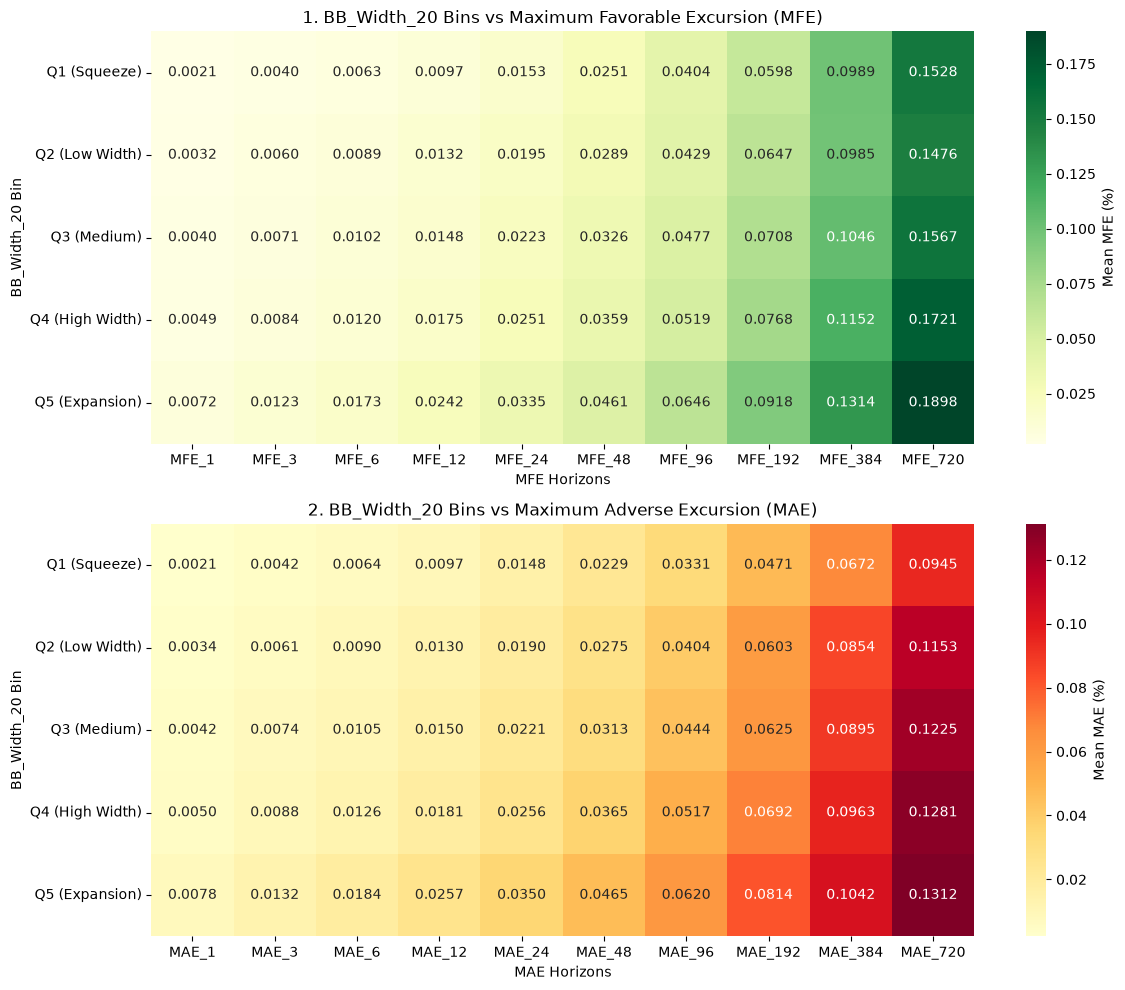

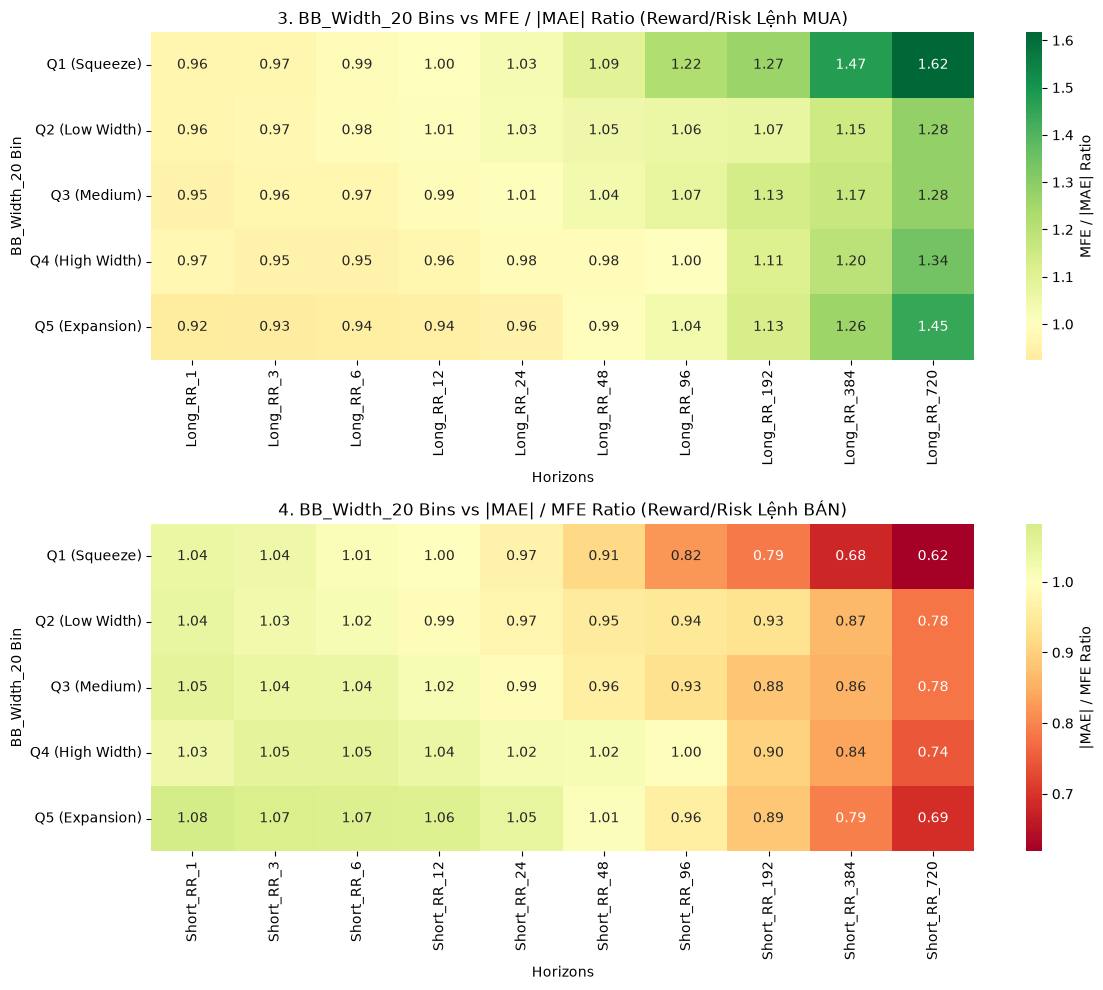

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. TIỀN XỬ LÝ BB_WIDTH_20 & TÁI CẤU TRÚC BỘ NHỚ
# ==========================================
n_bb = 20
if f'BB_Width_{n_bb}' not in df.columns:
    sma_20 = df['Close'].rolling(n_bb).mean()
    std_20 = df['Close'].rolling(n_bb).std()
    upper_band = sma_20 + 2 * std_20
    lower_band = sma_20 - 2 * std_20
    df[f'BB_Width_{n_bb}'] = ((upper_band - lower_band) / sma_20) * 100

if 'bb_width_bin' not in df.columns:
    bb_labels = ['Q1 (Squeeze)', 'Q2 (Low Width)', 'Q3 (Medium)', 'Q4 (High Width)', 'Q5 (Expansion)']
    bb_width_bin = pd.qcut(df[f'BB_Width_{n_bb}'].dropna(), q=5, labels=bb_labels)
    df = pd.concat([df, pd.DataFrame({'bb_width_bin': bb_width_bin})], axis=1)

# Tái cấu trúc bộ nhớ tránh PerformanceWarning
df = df.copy()

# ==========================================
# 2. LỌC CÁC CỘT MFE VÀ MAE CÓ SẴN TRONG DF
# ==========================================
mfe_cols = sorted([col for col in df.columns if col.startswith('MFE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)
mae_cols = sorted([col for col in df.columns if col.startswith('MAE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)

# Gom nhóm theo bb_width_bin và tính giá trị trung bình
mfe_summary = df.groupby('bb_width_bin', observed=False)[mfe_cols].mean()
mae_summary = df.groupby('bb_width_bin', observed=False)[mae_cols].mean()

# ==========================================
# 3. TRỰC QUAN HÓA MFE VÀ MAE THUẦN TÚY
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# Graph 1: MFE Heatmap (Biên độ tăng giá tối đa)
sns.heatmap(
    mfe_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlGn", 
    cbar_kws={'label': 'Mean MFE (%)'},
    ax=axes[0]
)
axes[0].set_title('1. BB_Width_20 Bins vs Maximum Favorable Excursion (MFE)', fontsize=12)
axes[0].set_xlabel('MFE Horizons')
axes[0].set_ylabel('BB_Width_20 Bin')

# Graph 2: MAE Heatmap (Biên độ sụt giảm tối đa)
sns.heatmap(
    mae_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Mean MAE (%)'},
    ax=axes[1]
)
axes[1].set_title('2. BB_Width_20 Bins vs Maximum Adverse Excursion (MAE)', fontsize=12)
axes[1].set_xlabel('MAE Horizons')
axes[1].set_ylabel('BB_Width_20 Bin')

plt.tight_layout()
plt.show()

# ==========================================
# 4. TRỰC QUAN HÓA TỶ LỆ MFE/MAE (LONG R:R) VÀ MAE/MFE (SHORT R:R)
# ==========================================
if len(mfe_cols) == len(mae_cols):
    # Long R:R = MFE / |MAE|
    long_ratio = mfe_summary.values / np.abs(mae_summary.values)
    long_ratio_df = pd.DataFrame(long_ratio, index=mfe_summary.index, columns=[col.replace('MFE_', 'Long_RR_') for col in mfe_cols])

    # Short R:R = |MAE| / MFE
    short_ratio = np.abs(mae_summary.values) / np.where(mfe_summary.values == 0, np.nan, mfe_summary.values)
    short_ratio_df = pd.DataFrame(short_ratio, index=mfe_summary.index, columns=[col.replace('MFE_', 'Short_RR_') for col in mfe_cols])

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    # Graph 3: MFE / |MAE| Ratio (Lệnh Mua)
    sns.heatmap(
        long_ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0, 
        cbar_kws={'label': 'MFE / |MAE| Ratio'},
        ax=axes[0]
    )
    axes[0].set_title('3. BB_Width_20 Bins vs MFE / |MAE| Ratio (Reward/Risk Lệnh MUA)', fontsize=12)
    axes[0].set_xlabel('Horizons')
    axes[0].set_ylabel('BB_Width_20 Bin')

    # Graph 4: |MAE| / MFE Ratio (Lệnh Bán)
    sns.heatmap(
        short_ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0, 
        cbar_kws={'label': '|MAE| / MFE Ratio'},
        ax=axes[1]
    )
    axes[1].set_title('4. BB_Width_20 Bins vs |MAE| / MFE Ratio (Reward/Risk Lệnh BÁN)', fontsize=12)
    axes[1].set_xlabel('Horizons')
    axes[1].set_ylabel('BB_Width_20 Bin')

    plt.tight_layout()
    plt.show()

/home/Sirius/DS/MarketPricePrediction/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4608: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


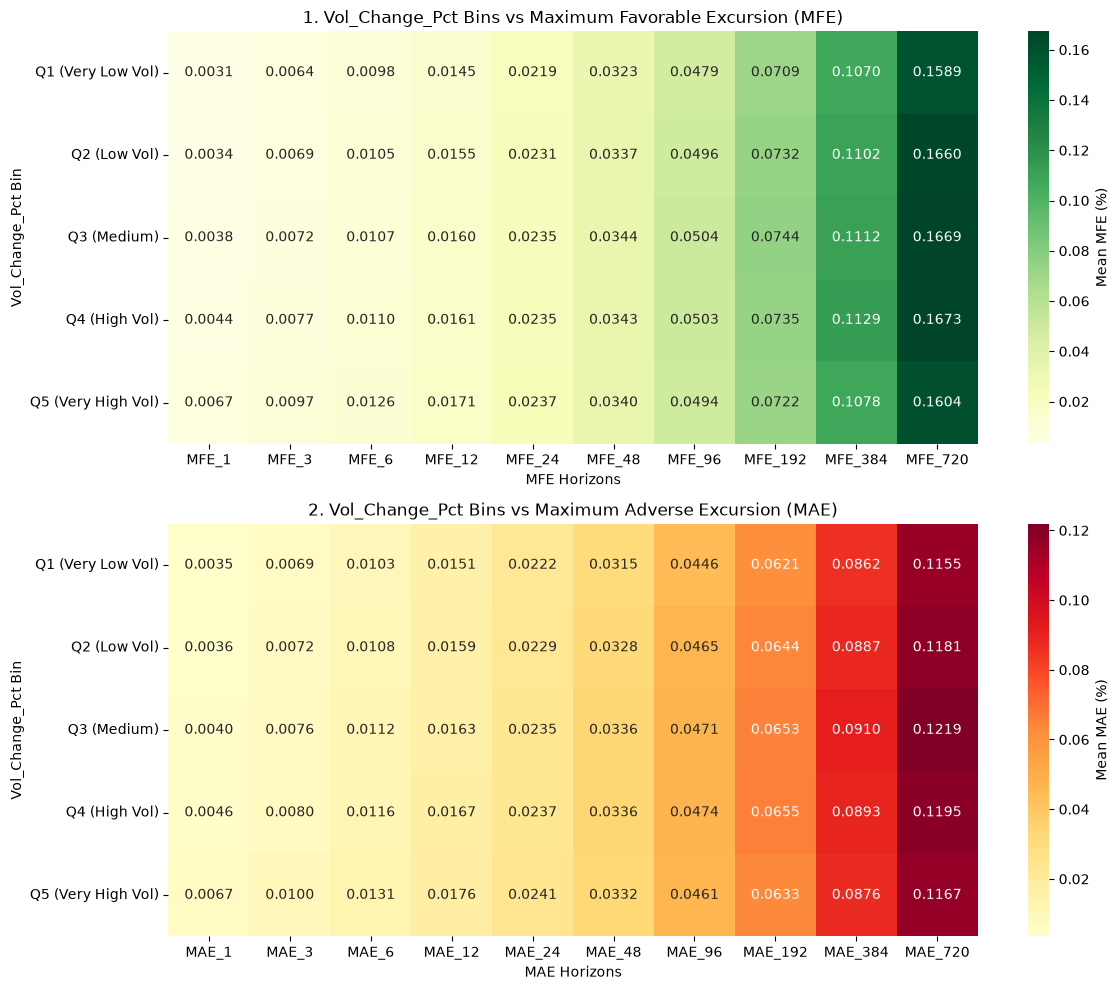

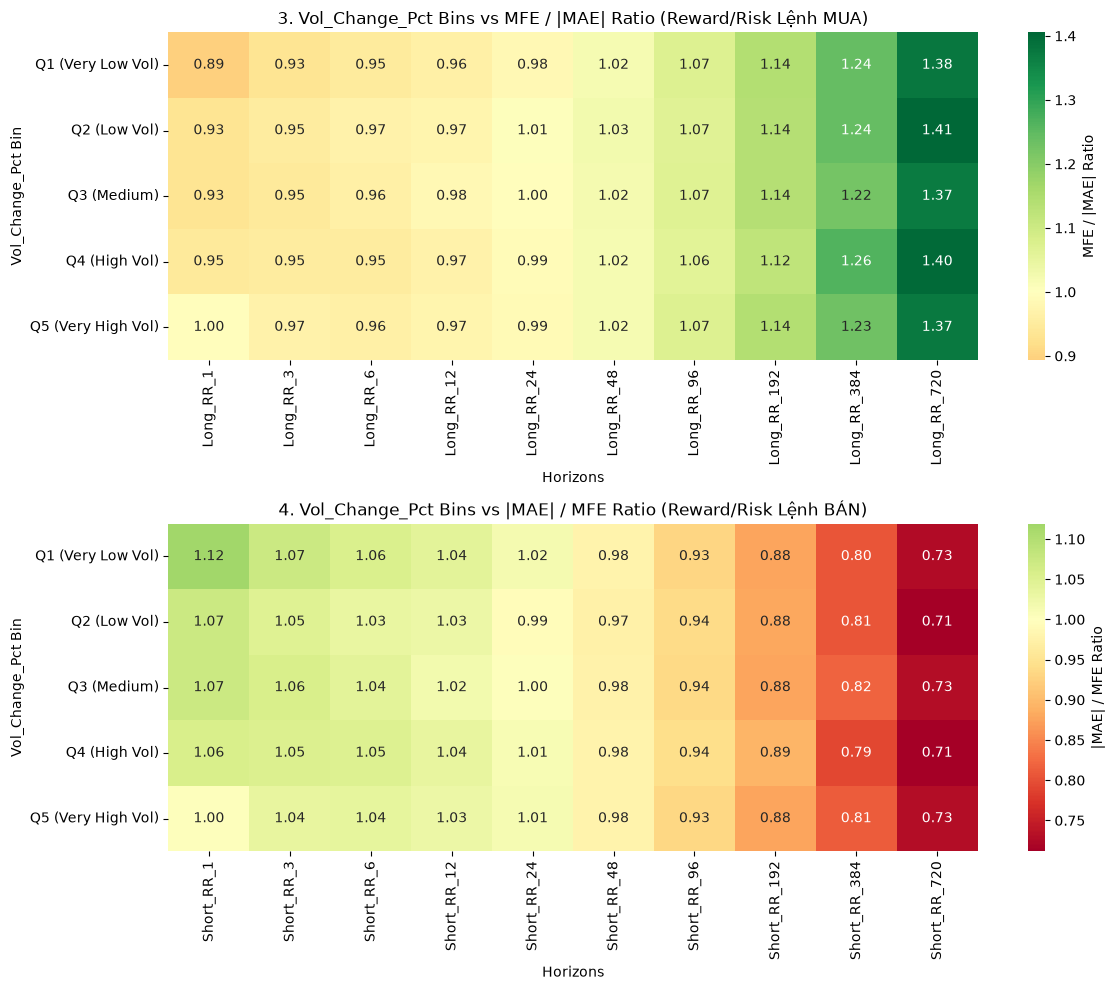

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. HỢP NHẤT VOL_DF VÀ TẠO VOLATILITY BINS
# ==========================================

# Chọn chỉ báo khối lượng muốn phân tích (ví dụ: Vol_Change_Pct hoặc Vol_SMA_20)
target_vol_col = 'Vol_Change_Pct' # Hoặc chọn 'Vol_SMA_20'

# Tạo nhãn phân loại theo 5 Quantile
vol_labels = ['Q1 (Very Low Vol)', 'Q2 (Low Vol)', 'Q3 (Medium)', 'Q4 (High Vol)', 'Q5 (Very High Vol)']
vol_bin_col = f'{target_vol_col}_bin'

# Chia Bins khối lượng
vol_bin_series = pd.qcut(df[target_vol_col].dropna(), q=5, labels=vol_labels)
df = pd.concat([df, pd.DataFrame({vol_bin_col: vol_bin_series})], axis=1).copy()

# ==========================================
# 2. LỌC CÁC CỘT MFE VÀ MAE CÓ SẴN TRONG DF
# ==========================================
mfe_cols = sorted([col for col in df.columns if col.startswith('MFE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)
mae_cols = sorted([col for col in df.columns if col.startswith('MAE_')], key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)

# Gom nhóm theo vol_bin_col và tính giá trị trung bình
mfe_summary = df.groupby(vol_bin_col, observed=False)[mfe_cols].mean()
mae_summary = df.groupby(vol_bin_col, observed=False)[mae_cols].mean()

# ==========================================
# 3. TRỰC QUAN HÓA MFE VÀ MAE
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# Graph 1: MFE Heatmap (Lợi nhuận tiềm năng theo Volume)
sns.heatmap(
    mfe_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlGn", 
    cbar_kws={'label': 'Mean MFE (%)'},
    ax=axes[0]
)
axes[0].set_title(f'1. {target_vol_col} Bins vs Maximum Favorable Excursion (MFE)', fontsize=12)
axes[0].set_xlabel('MFE Horizons')
axes[0].set_ylabel(f'{target_vol_col} Bin')

# Graph 2: MAE Heatmap (Rủi ro sụt giảm theo Volume)
sns.heatmap(
    mae_summary, 
    annot=True, 
    fmt=".4f", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Mean MAE (%)'},
    ax=axes[1]
)
axes[1].set_title(f'2. {target_vol_col} Bins vs Maximum Adverse Excursion (MAE)', fontsize=12)
axes[1].set_xlabel('MAE Horizons')
axes[1].set_ylabel(f'{target_vol_col} Bin')

plt.tight_layout()
plt.show()

# ==========================================
# 4. TRỰC QUAN HÓA TỶ LỆ MFE/MAE (LONG R:R) VÀ MAE/MFE (SHORT R:R)
# ==========================================
if len(mfe_cols) == len(mae_cols):
    # Long R:R = MFE / |MAE|
    long_ratio = mfe_summary.values / np.abs(mae_summary.values)
    long_ratio_df = pd.DataFrame(long_ratio, index=mfe_summary.index, columns=[col.replace('MFE_', 'Long_RR_') for col in mfe_cols])

    # Short R:R = |MAE| / MFE
    short_ratio = np.abs(mae_summary.values) / np.where(mfe_summary.values == 0, np.nan, mfe_summary.values)
    short_ratio_df = pd.DataFrame(short_ratio, index=mfe_summary.index, columns=[col.replace('MFE_', 'Short_RR_') for col in mfe_cols])

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    # Graph 3: MFE / |MAE| Ratio (Lệnh Mua)
    sns.heatmap(
        long_ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0, 
        cbar_kws={'label': 'MFE / |MAE| Ratio'},
        ax=axes[0]
    )
    axes[0].set_title(f'3. {target_vol_col} Bins vs MFE / |MAE| Ratio (Reward/Risk Lệnh MUA)', fontsize=12)
    axes[0].set_xlabel('Horizons')
    axes[0].set_ylabel(f'{target_vol_col} Bin')

    # Graph 4: |MAE| / MFE Ratio (Lệnh Bán)
    sns.heatmap(
        short_ratio_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdYlGn", 
        center=1.0, 
        cbar_kws={'label': '|MAE| / MFE Ratio'},
        ax=axes[1]
    )
    axes[1].set_title(f'4. {target_vol_col} Bins vs |MAE| / MFE Ratio (Reward/Risk Lệnh BÁN)', fontsize=12)
    axes[1].set_xlabel('Horizons')
    axes[1].set_ylabel(f'{target_vol_col} Bin')

    plt.tight_layout()
    plt.show()

In [11]:
print(barrier_df['Meta_Target_Binary'].value_counts())
print('Is NaN:', barrier_df['Meta_Target_Binary'].isna().sum())

Meta_Target_Binary
0.0    15043
1.0     6096
Name: count, dtype: int64
Is NaN: 34349


-> Danh sách EMA: ['EMA_3', 'EMA_5', 'EMA_8', 'EMA_10', 'EMA_12', 'EMA_14', 'EMA_15', 'EMA_20', 'EMA_21', 'EMA_26', 'EMA_30', 'EMA_34', 'EMA_40', 'EMA_50', 'EMA_100', 'EMA_150', 'EMA_200', 'EMA_250']
-> Các Horizon (n phiên) tìm thấy: [1, 3, 6, 12, 24, 48, 96, 192, 384, 720]


/tmp/ipykernel_1772/2855198429.py:80: RuntimeWarning: divide by zero encountered in divide
  rr_long_series = np.where(valid_long, mfe_l_arr / mae_l_arr, np.nan)
/tmp/ipykernel_1772/2855198429.py:91: RuntimeWarning: divide by zero encountered in divide
  rr_short_series = np.where(valid_short, mae_s_arr / mfe_s_arr, np.nan)


=== TOP 5 LONG (Median R:R, Horizon = 720 nến, Min Signals = 10) ===
           EMA_Pair  Long_Signals   Long_RR
0    EMA_3 x EMA_40            55  1.865452
1  EMA_12 x EMA_250            70  1.806835
2   EMA_8 x EMA_250            30  1.782297
3  EMA_10 x EMA_250            58  1.727691
4  EMA_14 x EMA_250            91  1.674900

=== TOP 5 SHORT (Median R:R, Horizon = 720 nến, Min Signals = 10) ===
         EMA_Pair  Short_Signals  Short_RR
0  EMA_3 x EMA_30             99  1.287582
1  EMA_5 x EMA_50             84  1.221113
2  EMA_5 x EMA_26            229  1.132696
3  EMA_5 x EMA_30            181  1.041309
4  EMA_5 x EMA_34            143  1.037578


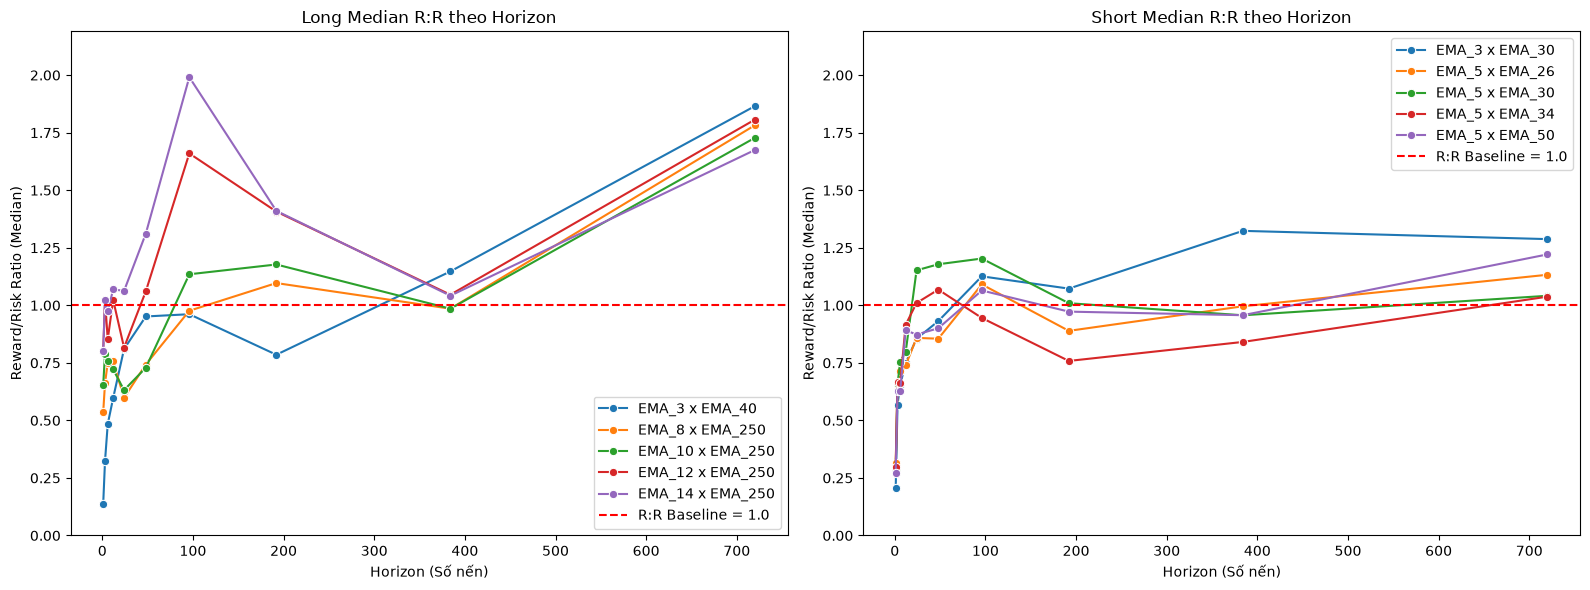

In [12]:
import itertools
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import talib

# ==========================================
# 1. TỰ ĐỘNG TÌM VÀ SẮP XẾP CÁC CỘT
# ==========================================
high_col = next((c for c in df.columns if c.lower() == 'high'), 'High')
low_col = next((c for c in df.columns if c.lower() == 'low'), 'Low')
close_col = next((c for c in df.columns if c.lower() == 'close'), 'Close')

# Lọc cột EMA
ema_cols = [c for c in df.columns if c.startswith('EMA_')]
ema_cols = sorted(ema_cols, key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 0)

# Lọc các Horizon n
mfe_cols = [c for c in df.columns if c.startswith('MFE_')]
mae_cols = [c for c in df.columns if c.startswith('MAE_')]

horizons = sorted(list(set([
    int(re.search(r'\d+', c).group()) for c in mfe_cols + mae_cols if re.search(r'\d+', c)
])))

print(f"-> Danh sách EMA: {ema_cols}")
print(f"-> Các Horizon (n phiên) tìm thấy: {horizons}")

# ==========================================
# 2. BỘ LỌC TREND (TÍNH 1 LẦN DUY NHẤT)
# ==========================================
is_trending = df['ADX'] > 20

# ==========================================
# 3. TÍNH R:R MEDIAN CHO TỪNG HORIZON
# ==========================================
results = []
slope_lookback = 5
min_signals_threshold = 10  # Bộ lọc: Ít nhất 10 tín hiệu mới tính R:R

for fast_col, slow_col in itertools.combinations(ema_cols, 2):
    fast_span = int(re.search(r'\d+', fast_col).group())
    slow_span = int(re.search(r'\d+', slow_col).group())
    
    if fast_span > slow_span:
        fast_col, slow_col = slow_col, fast_col
        
    fast_s = df[fast_col]
    slow_s = df[slow_col]
    
    # Tính độ dốc EMA Chậm
    slow_slope = slow_s.pct_change(slope_lookback) * 100
    
    # Tín hiệu Crossover
    long_cross = (fast_s > slow_s) & (fast_s.shift(1) <= slow_s.shift(1)) & is_trending & (slow_slope > 0.03)
    short_cross = (fast_s < slow_s) & (fast_s.shift(1) >= slow_s.shift(1)) & is_trending & (slow_slope < -0.03)
    
    long_sub = df[long_cross]
    short_sub = df[short_cross]
    
    long_count = len(long_sub)
    short_count = len(short_sub)
    
    for h in horizons:
        mfe_col_h = f"MFE_{h}"
        mae_col_h = f"MAE_{h}"
        
        if mfe_col_h not in df.columns or mae_col_h not in df.columns:
            continue
        
        # --- LONG: TÍNH R:R TỪNG LỆNH RỒI LẤY MEDIAN ---
        if long_count >= min_signals_threshold:
            mfe_l_arr = long_sub[mfe_col_h].values
            mae_l_arr = np.abs(long_sub[mae_col_h].values)
            
            # Tính R:R từng lệnh (tránh chia cho 0)
            valid_long = mae_l_arr > 0
            rr_long_series = np.where(valid_long, mfe_l_arr / mae_l_arr, np.nan)
            long_rr = np.nanmedian(rr_long_series)
        else:
            long_rr = np.nan
            
        # --- SHORT: TÍNH R:R TỪNG LỆNH RỒI LẤY MEDIAN ---
        if short_count >= min_signals_threshold:
            mfe_s_arr = short_sub[mfe_col_h].values
            mae_s_arr = np.abs(short_sub[mae_col_h].values)
            
            valid_short = mfe_s_arr > 0
            rr_short_series = np.where(valid_short, mae_s_arr / mfe_s_arr, np.nan)
            short_rr = np.nanmedian(rr_short_series)
        else:
            short_rr = np.nan
            
        results.append({
            'EMA_Pair': f"{fast_col} x {slow_col}",
            'Horizon': h,
            'Long_Signals': long_count,
            'Long_RR': long_rr,
            'Short_Signals': short_count,
            'Short_RR': short_rr
        })

detailed_df = pd.DataFrame(results)

# ==========================================
# 4. TRUẤT XUẤT TOP CẶP EMA VÀ VẼ ĐỒ THỊ
# ==========================================
h_target = horizons[-1] 
target_df = detailed_df[detailed_df['Horizon'] == h_target].dropna(subset=['Long_RR', 'Short_RR'], how='all')

top_long = target_df.sort_values(by='Long_RR', ascending=False).reset_index(drop=True)
top_short = target_df.sort_values(by='Short_RR', ascending=False).reset_index(drop=True)

print(f"=== TOP 5 LONG (Median R:R, Horizon = {h_target} nến, Min Signals = {min_signals_threshold}) ===")
print(top_long[['EMA_Pair', 'Long_Signals', 'Long_RR']].head(5))

print(f"\n=== TOP 5 SHORT (Median R:R, Horizon = {h_target} nến, Min Signals = {min_signals_threshold}) ===")
print(top_short[['EMA_Pair', 'Short_Signals', 'Short_RR']].head(5))

# ==========================================
# 5. TRỰC QUAN HÓA VÀ ĐỒNG BỘ TRỤC Y
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_pairs_long = top_long['EMA_Pair'].head(5).tolist()
top_pairs_short = top_short['EMA_Pair'].head(5).tolist()

plot_long_df = detailed_df[detailed_df['EMA_Pair'].isin(top_pairs_long)]
plot_short_df = detailed_df[detailed_df['EMA_Pair'].isin(top_pairs_short)]

# Đồ thị Long
sns.lineplot(data=plot_long_df, x='Horizon', y='Long_RR', hue='EMA_Pair', marker='o', ax=axes[0])
axes[0].axhline(1.0, color='red', linestyle='--', label='R:R Baseline = 1.0')
axes[0].set_title('Long Median R:R theo Horizon', fontsize=12)
axes[0].set_xlabel('Horizon (Số nến)')
axes[0].set_ylabel('Reward/Risk Ratio (Median)')
axes[0].legend()

# Đồ thị Short
sns.lineplot(data=plot_short_df, x='Horizon', y='Short_RR', hue='EMA_Pair', marker='o', ax=axes[1])
axes[1].axhline(1.0, color='red', linestyle='--', label='R:R Baseline = 1.0')
axes[1].set_title('Short Median R:R theo Horizon', fontsize=12)
axes[1].set_xlabel('Horizon (Số nến)')
axes[1].set_ylabel('Reward/Risk Ratio (Median)')
axes[1].legend()

# Đồng bộ giới hạn trục Y
y_max = max(plot_long_df['Long_RR'].max(), plot_short_df['Short_RR'].max()) * 1.1
axes[0].set_ylim(0, y_max)
axes[1].set_ylim(0, y_max)

plt.tight_layout()
plt.show()